In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [4]:
# =========================
# 1. 基本設定
# =========================
#base_dir = Path("/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_最高溫/GWL1.5") #Mac
# <<< 改這裡/Users/stevechiao #"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\GWL1.5"
base_dir = Path("\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\GWL1.5") #window
models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]
gwl_folder = "GWL1.5"
start_year = 1996
end_year = 2036
start_date = pd.Timestamp(f"{start_year}-01-01")
end_date   = pd.Timestamp(f"{end_year}-12-31")

poi_lat = 25.0190099143756
poi_lon = 121.53137177116402


In [5]:
print(list(base_dir.glob("*.csv"))[:5])

[PosixPath('/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_最高溫/GWL1.5/AR6_統計降尺度_日資料_臺北市_最高溫_ssp126_IITM-ESM_2043.csv'), PosixPath('/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_最高溫/GWL1.5/AR6_統計降尺度_日資料_臺北市_最高溫_ssp370_EC-Earth3-Veg_2004.csv'), PosixPath('/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_最高溫/GWL1.5/AR6_統計降尺度_日資料_臺北市_最高溫_ssp370_EC-Earth3-Veg_2010.csv'), PosixPath('/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_最高溫/GWL1.5/AR6_統計降尺度_日資料_臺北市_最高溫_ssp245_INM-CM4-8_2033.csv'), PosixPath('/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_最高溫/GWL1.5/AR6_統計降尺度_日資料_臺北市_最高溫_ssp370_CMCC-ESM2_2038.csv')]


In [7]:
def read_one_tccip_grid_csv(csv_path, poi_lon, poi_lat):
    df = pd.read_csv(csv_path)

    # 前兩欄通常是經度、緯度
    lon_col = df.columns[0]
    lat_col = df.columns[1]

    # 找最近格點
    df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)
    nearest = df.loc[df["dist"].idxmin()].copy()

    # 抓出這個格點的經緯度
    nearest_lon = nearest[lon_col]
    nearest_lat = nearest[lat_col]

    # 第3欄之後都是時間序列
    value_cols = df.columns[2:-1] if df.columns[-1] == "dist" else df.columns[2:]
    values = pd.to_numeric(nearest[value_cols], errors="coerce").replace(-99.9, np.nan)

    # 從檔名抓年份
    # 例如：AR6_統計降尺度_日資料_臺北市_最高溫_ssp126_ACCESS-CM2_2018.csv
    year_str = csv_path.stem.split("_")[-1]
    year = int(year_str)

    # 建立日期
    dates = pd.date_range(f"{year}-01-01", periods=len(values), freq="D")

    ts = pd.DataFrame({
        "time": dates,
        "tmax": values.values
    })

    return ts, nearest_lon, nearest_lat

In [8]:
def find_csv_files_flat(base_dir, model, ssp):
    files = []
    for f in base_dir.glob("*.csv"):
        name = f.name
        if ("最高溫" in name) and (ssp in name) and (model in name):
            files.append(f)
    return sorted(files)

In [9]:
def read_all_years_for_model_ssp(base_dir, model, ssp, poi_lon, poi_lat):
    files = find_csv_files_flat(base_dir, model, ssp)

    if len(files) == 0:
        return None, None

    dfs = []
    nearest_info = None

    for f in files:
        try:
            ts, nearest_lon, nearest_lat = read_one_tccip_grid_csv(f, poi_lon, poi_lat)
            dfs.append(ts)

            if nearest_info is None:
                nearest_info = (nearest_lon, nearest_lat)

        except Exception as e:
            print(f"❌ 讀取失敗: {f.name} -> {e}")

    if len(dfs) == 0:
        return None, None

    combined = pd.concat(dfs, ignore_index=True)
    combined = combined.drop_duplicates(subset=["time"]).sort_values("time")

    return combined, nearest_info

In [10]:
def add_season_info(df):
    df = df.copy()
    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month

    season_map = {
        12: "DJF", 1: "DJF", 2: "DJF",
        3: "MAM", 4: "MAM", 5: "MAM",
        6: "JJA", 7: "JJA", 8: "JJA",
        9: "SON", 10: "SON", 11: "SON"
    }
    df["season"] = df["month"].map(season_map)

    df["season_year"] = df["year"]
    df.loc[df["month"] == 12, "season_year"] += 1

    return df

def calc_seasonal_max(df):
    df = add_season_info(df)

    seasonal_max = (
        df.groupby(["season_year", "season"], as_index=False)["tmax"]
        .max()
        .rename(columns={"season_year": "year", "tmax": "seasonal_max_tmax"})
    )
    return seasonal_max


In [11]:
base_dir = Path("/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_最高溫/GWL1.5")

models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]

poi_lon = 121.53
poi_lat = 25.02

all_data = []

for model in models:
    for ssp in ssps:
        df, nearest_info = read_all_years_for_model_ssp(base_dir, model, ssp, poi_lon, poi_lat)

        if df is None or len(df) == 0:
            print(f"⚠️ 找不到資料: {model} / {ssp}")
            continue

        seasonal_max = calc_seasonal_max(df)
        seasonal_max["model"] = model
        seasonal_max["ssp"] = ssp
        all_data.append(seasonal_max)

        print(f"✅ 成功讀取: {model} / {ssp}")
        print(f"   最近格點 = lon {nearest_info[0]:.2f}, lat {nearest_info[1]:.2f}")

result = pd.concat(all_data, ignore_index=True)

/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)
/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)


✅ 成功讀取: TaiESM1 / ssp126
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: TaiESM1 / ssp245
   最近格點 = lon 121.53, lat 25.02


/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)
/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)


✅ 成功讀取: TaiESM1 / ssp370
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: TaiESM1 / ssp585
   最近格點 = lon 121.53, lat 25.02


/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)
/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)


...

✅ 成功讀取: EC-Earth3 / ssp245
   最近格點 = lon 121.53, lat 25.02


/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)


✅ 成功讀取: EC-Earth3 / ssp370
   最近格點 = lon 121.53, lat 25.02


/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)


✅ 成功讀取: EC-Earth3 / ssp585
   最近格點 = lon 121.53, lat 25.02


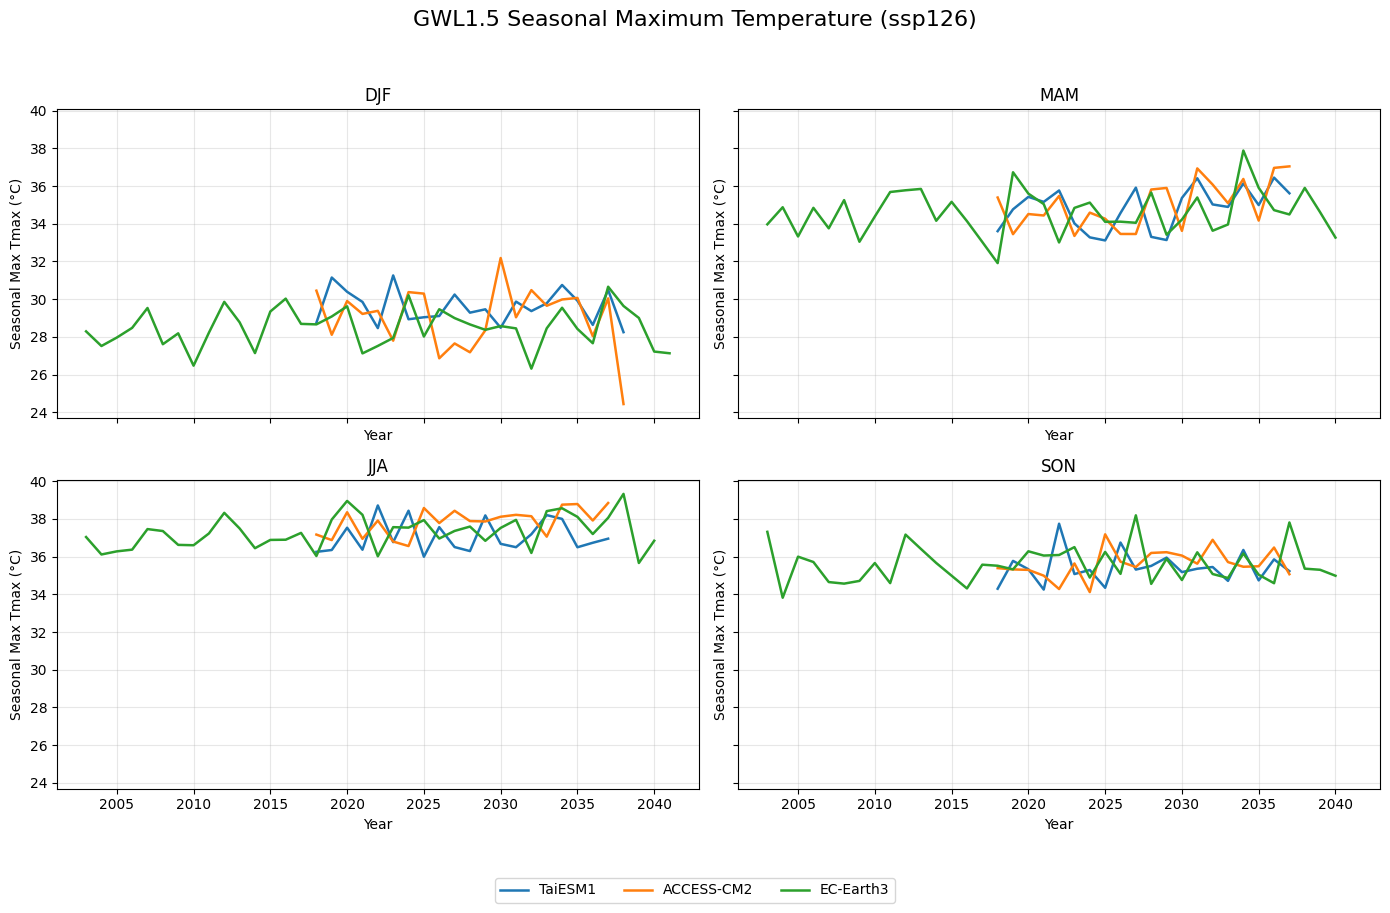

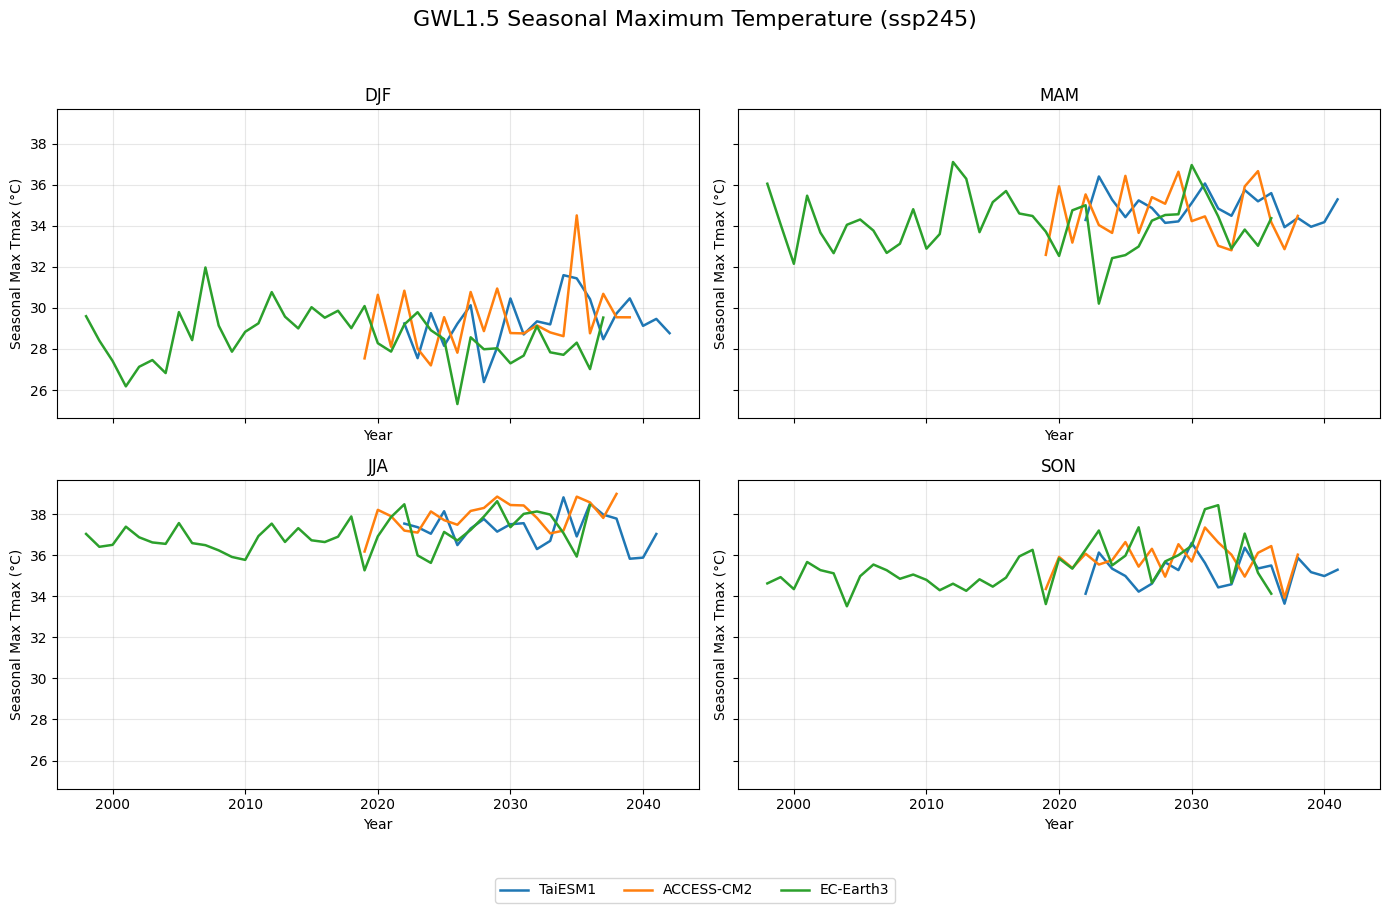

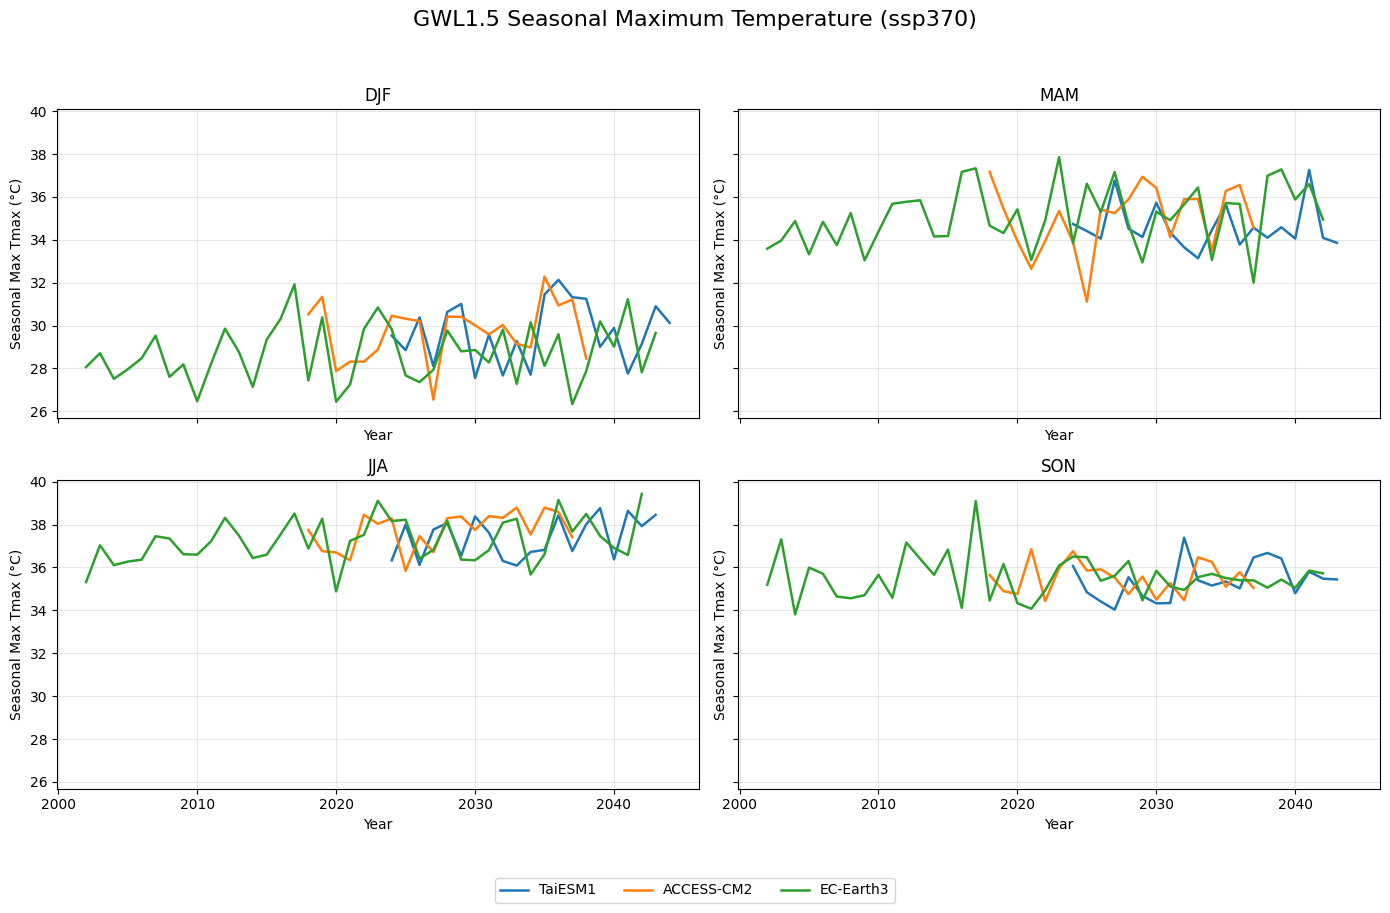

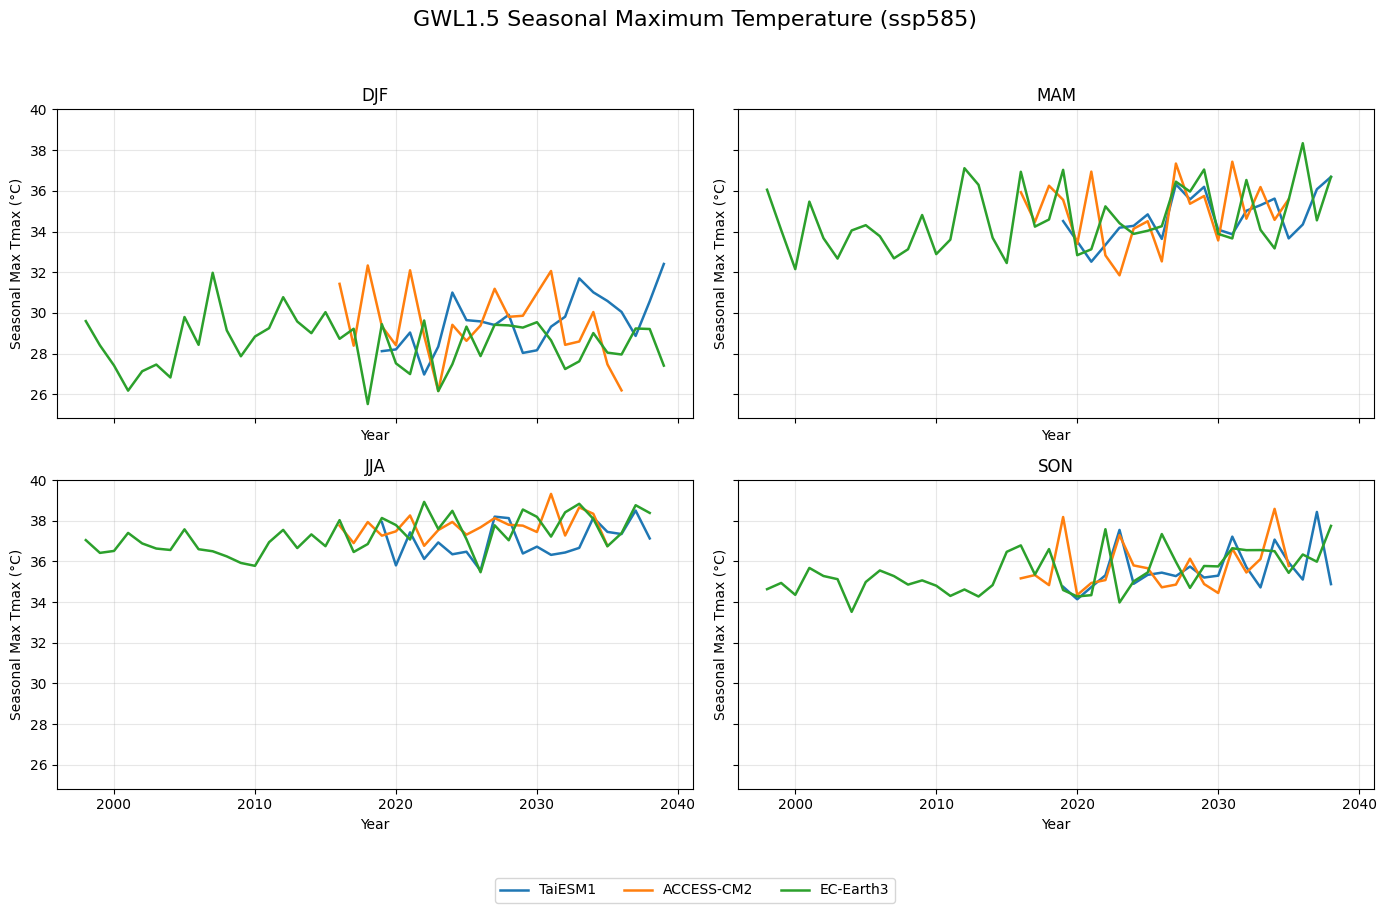

In [12]:
season_order = ["DJF", "MAM", "JJA", "SON"]

for ssp in ssps:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, season in zip(axes, season_order):
        sub = result[(result["ssp"] == ssp) & (result["season"] == season)]

        for model in models:
            line_data = sub[sub["model"] == model].sort_values("year")
            if len(line_data) == 0:
                continue

            ax.plot(
                line_data["year"],
                line_data["seasonal_max_tmax"],
                label=model,
                linewidth=1.8
            )

        ax.set_title(season)
        ax.set_xlabel("Year")
        ax.set_ylabel("Seasonal Max Tmax (°C)")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f"GWL1.5 Seasonal Maximum Temperature ({ssp})", fontsize=16)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

In [14]:
#畫盒鬚圖
base_dir = Path("/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_最高溫/GWL1.5")

models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]

poi_lon = 121.53
poi_lat = 25.02

daily_data = []

for model in models:
    for ssp in ssps:
        df, nearest_info = read_all_years_for_model_ssp(base_dir, model, ssp, poi_lon, poi_lat)

        if df is None or len(df) == 0:
            print(f"⚠️ 找不到資料: {model} / {ssp}")
            continue

        df = add_season_info(df)
        df["model"] = model
        df["ssp"] = ssp
        daily_data.append(df)

        #print(f"✅ 成功讀取: {model} / {ssp}")
        #print(f"   最近格點 = lon {nearest_info[0]:.2f}, lat {nearest_info[1]:.2f}")

daily_result = pd.concat(daily_data, ignore_index=True)

/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)
/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist"] = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)
/var/folders/_q/f17jh5414y3_0vq8gvppzhpr0000gn/T/ipykernel_99945/1592028863.py:9: PerformanceWarning: DataFrame is highly 

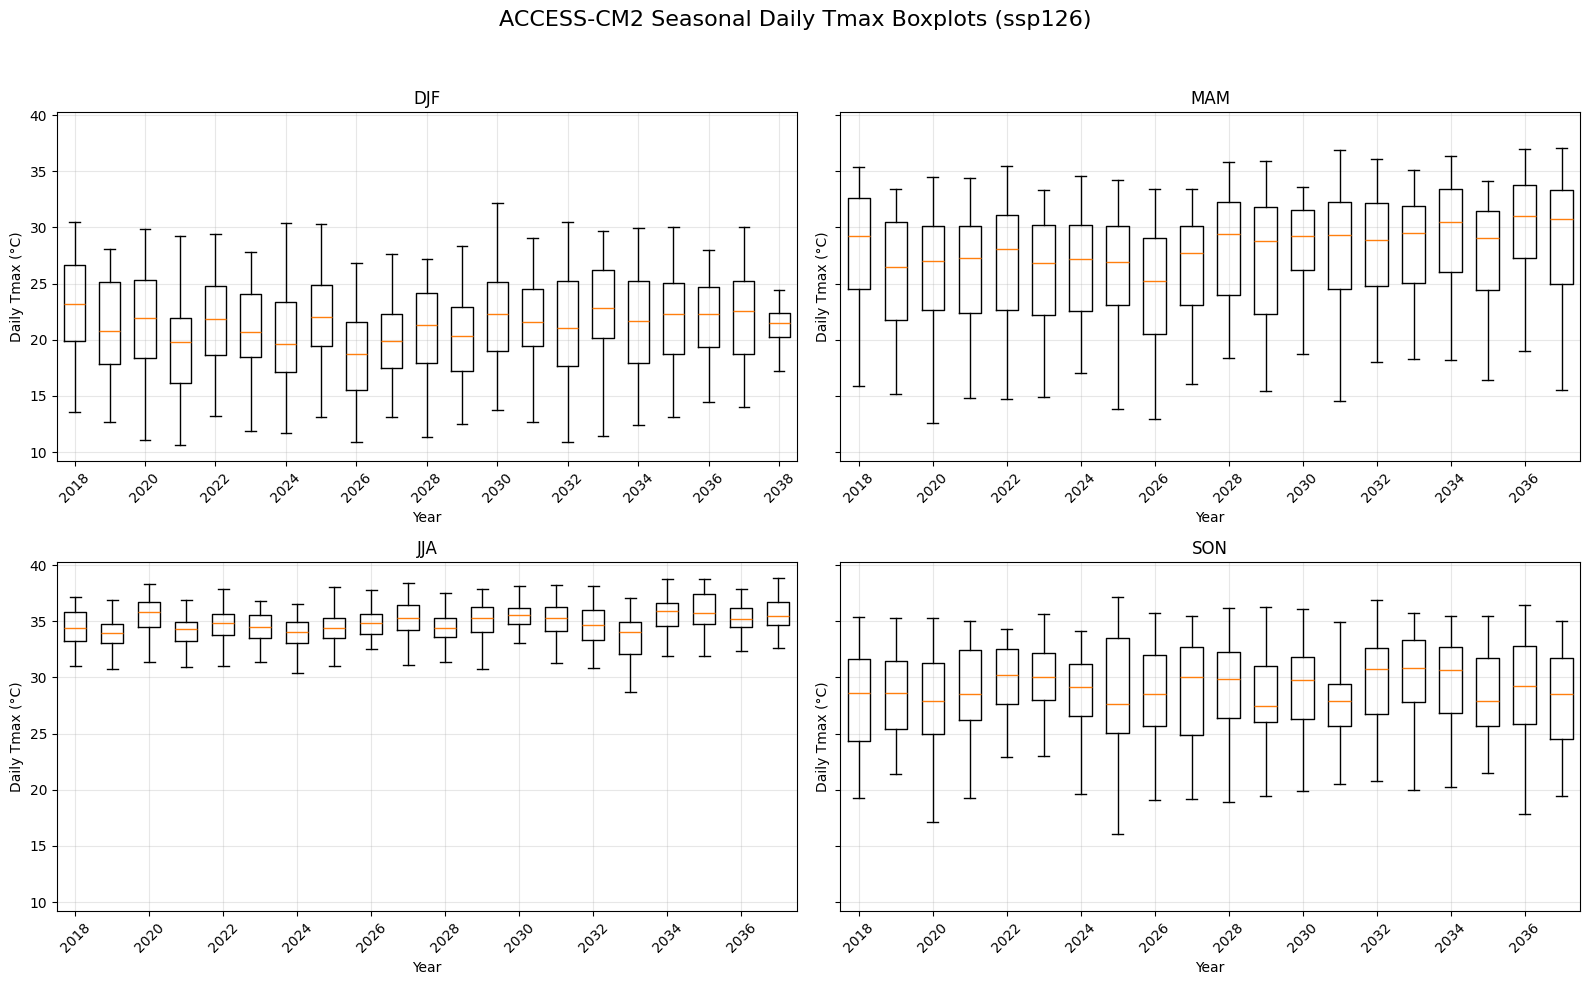

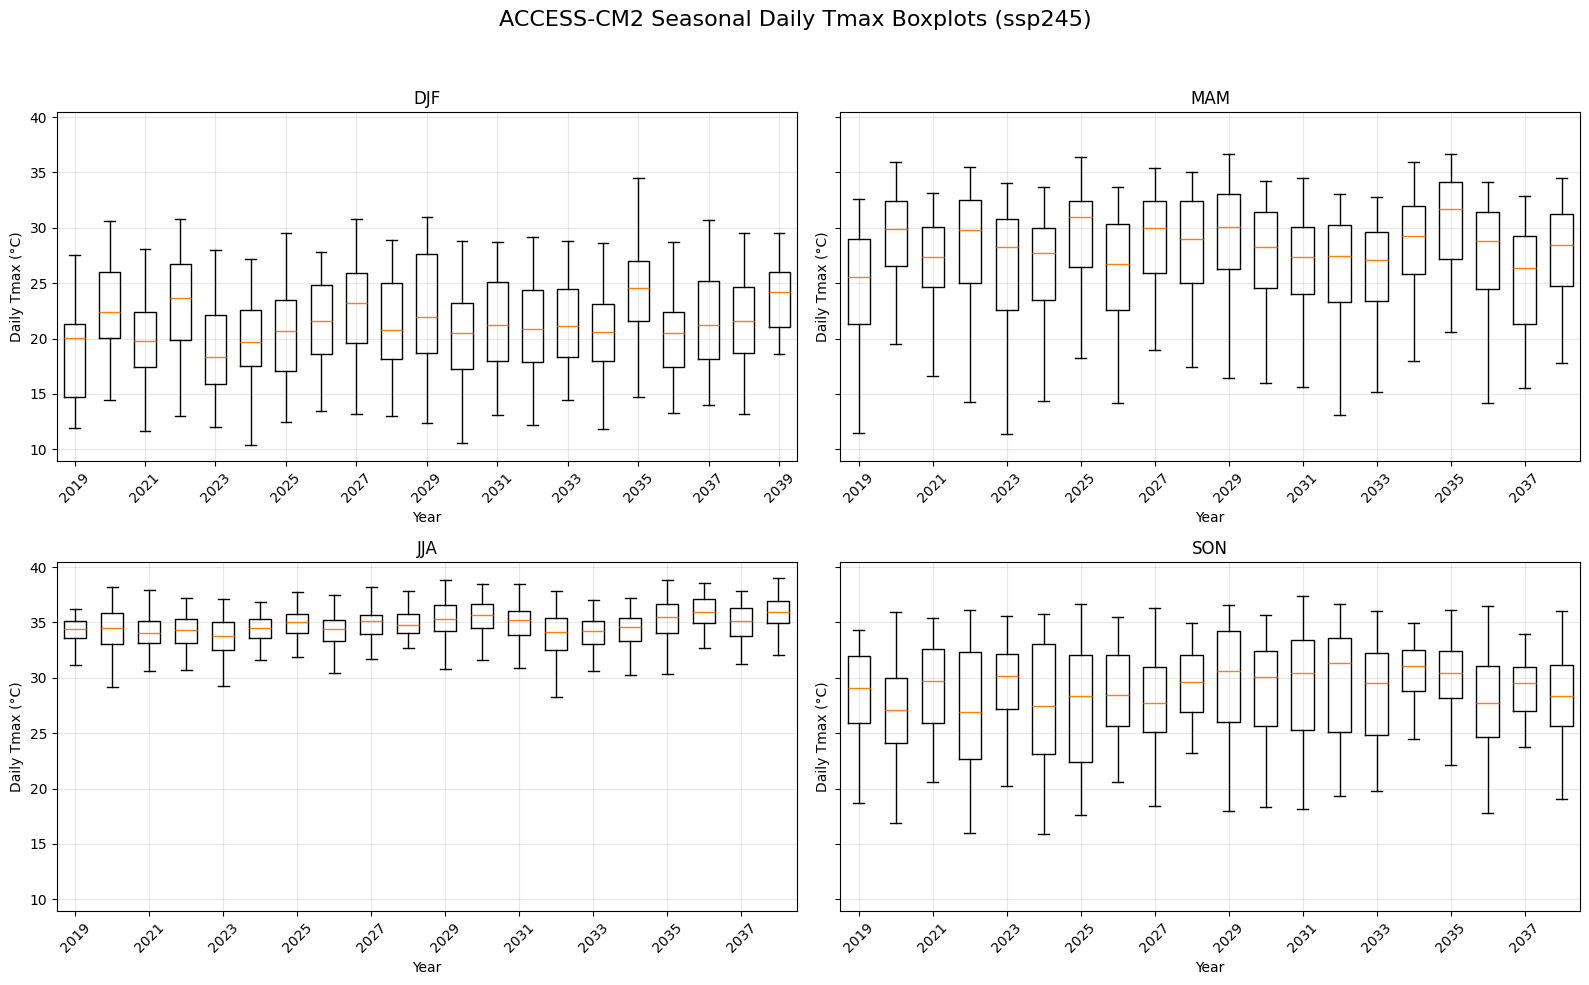

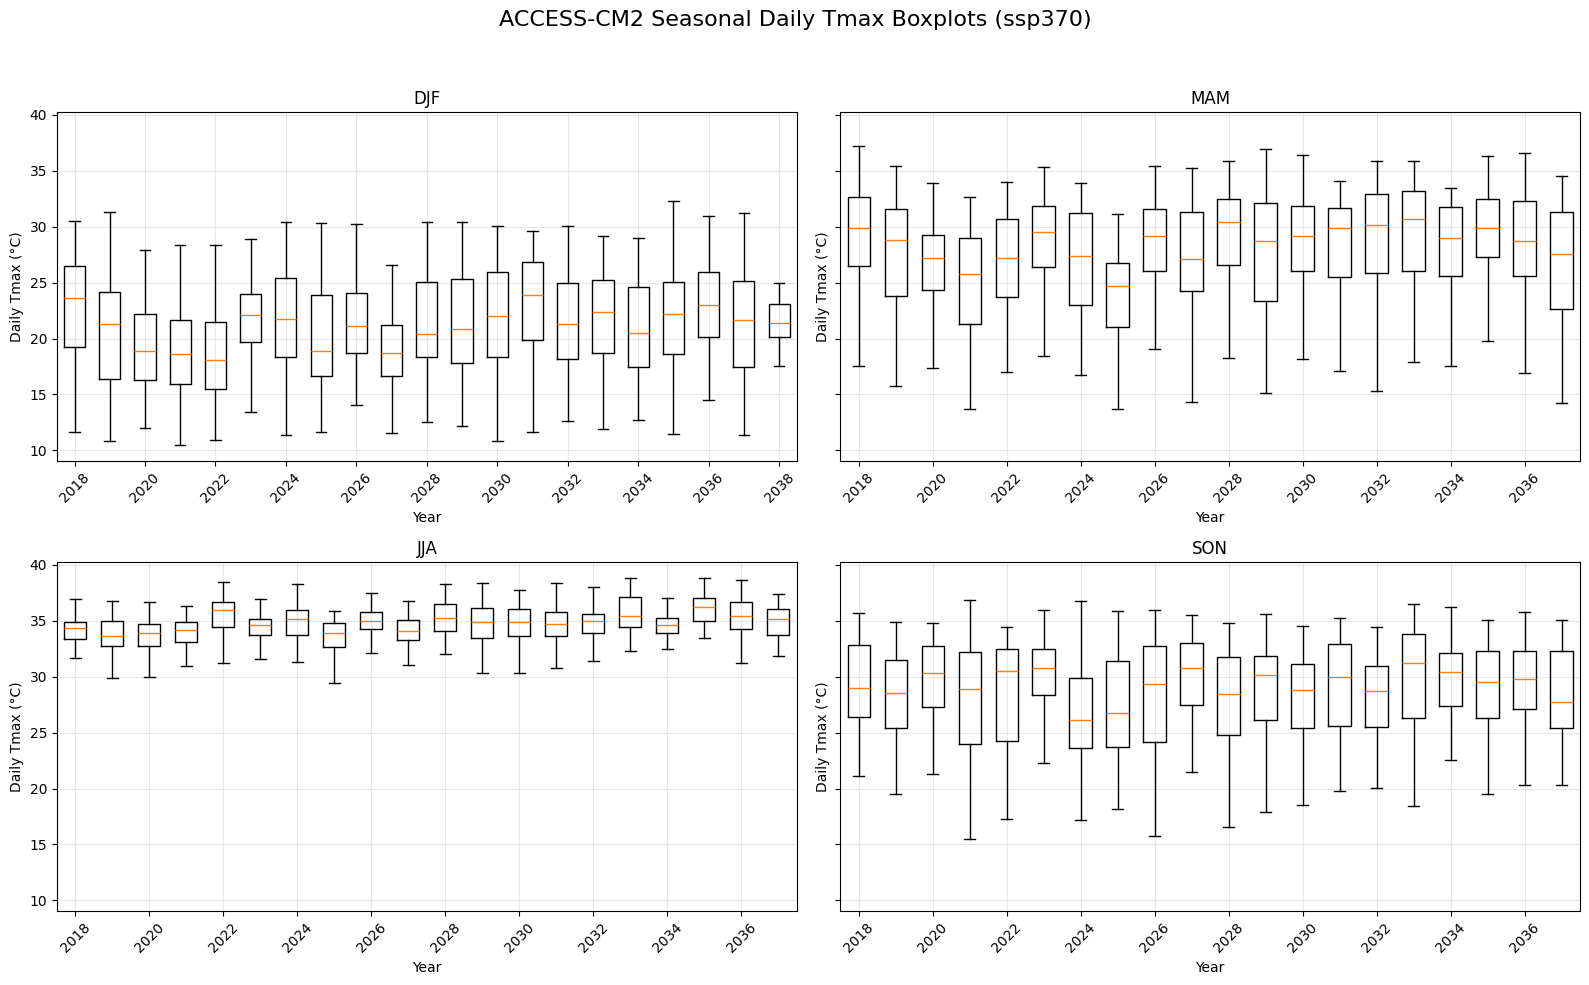

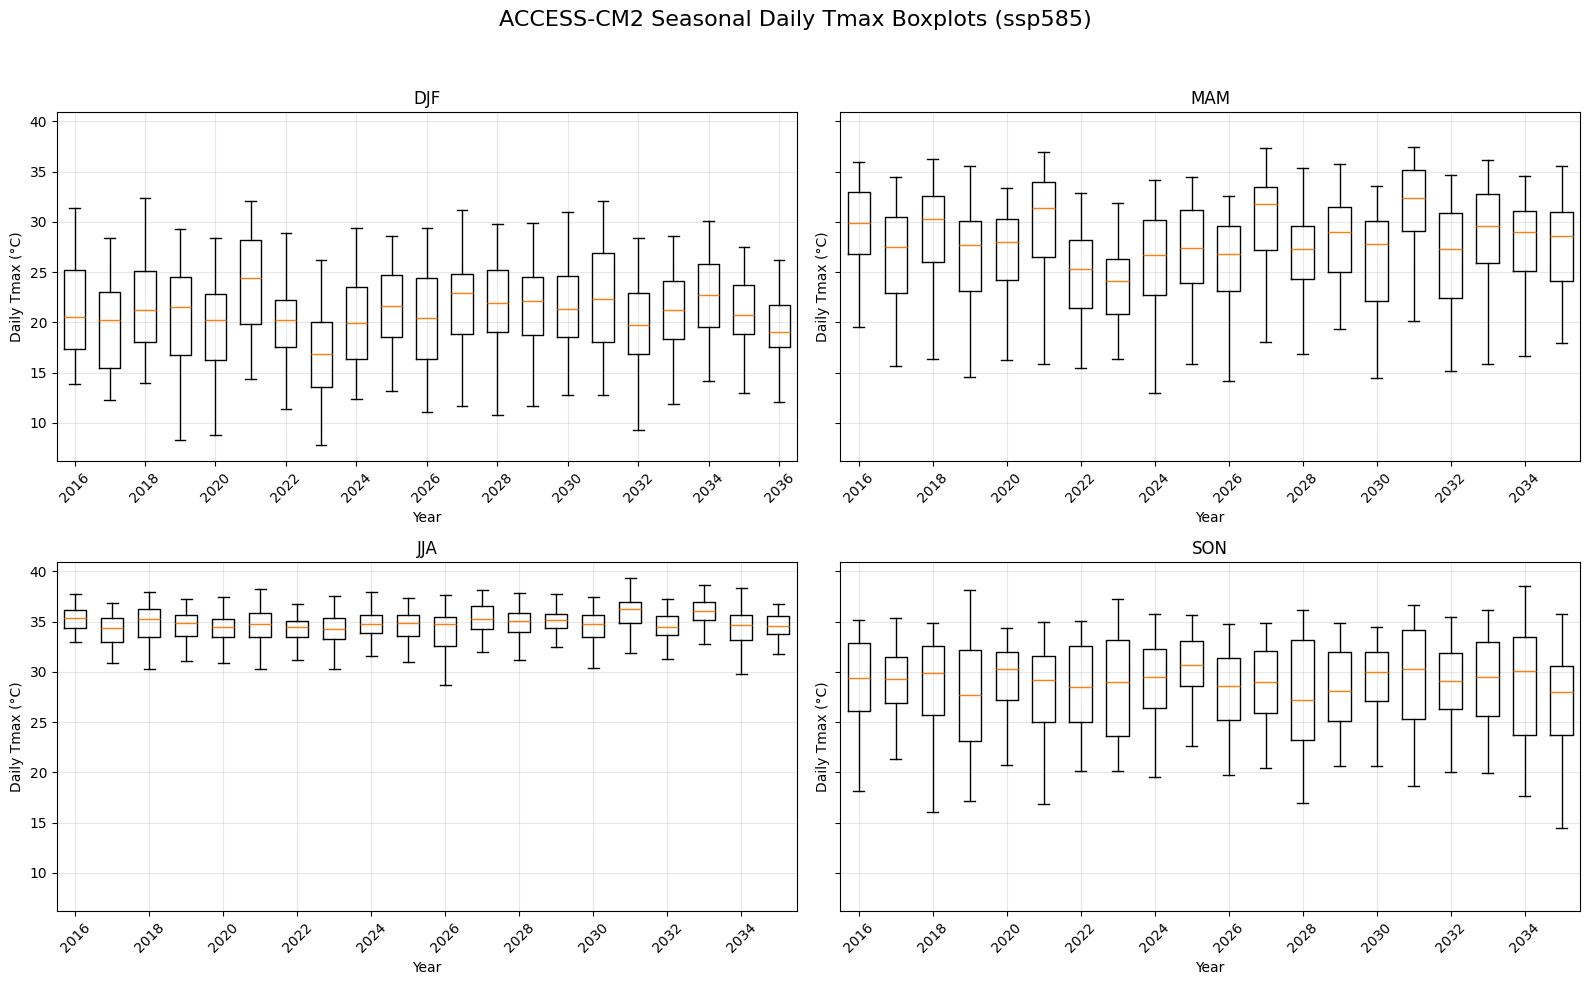

In [15]:
import matplotlib.pyplot as plt

season_order = ["DJF", "MAM", "JJA", "SON"]
target_model = "ACCESS-CM2"

for ssp in ssps:
    sub_all = daily_result[
        (daily_result["ssp"] == ssp) &
        (daily_result["model"] == target_model)
    ].copy()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()

    for ax, season in zip(axes, season_order):
        sub = sub_all[sub_all["season"] == season].copy()

        years = sorted(sub["season_year"].dropna().unique())

        box_data = []
        valid_years = []

        for y in years:
            vals = sub.loc[sub["season_year"] == y, "tmax"].dropna().values
            if len(vals) > 0:
                box_data.append(vals)
                valid_years.append(int(y))

        if len(box_data) == 0:
            ax.set_title(season)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            continue

        ax.boxplot(
            box_data,
            positions=range(len(valid_years)),
            widths=0.6,
            patch_artist=False,
            showfliers=False
        )

        # x 軸不要全部年份都擠在一起
        step = max(1, len(valid_years) // 8)
        tick_idx = list(range(0, len(valid_years), step))

        ax.set_xticks(tick_idx)
        ax.set_xticklabels([valid_years[i] for i in tick_idx], rotation=45)

        ax.set_title(season)
        ax.set_xlabel("Year")
        ax.set_ylabel("Daily Tmax (°C)")
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"{target_model} Seasonal Daily Tmax Boxplots ({ssp})", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

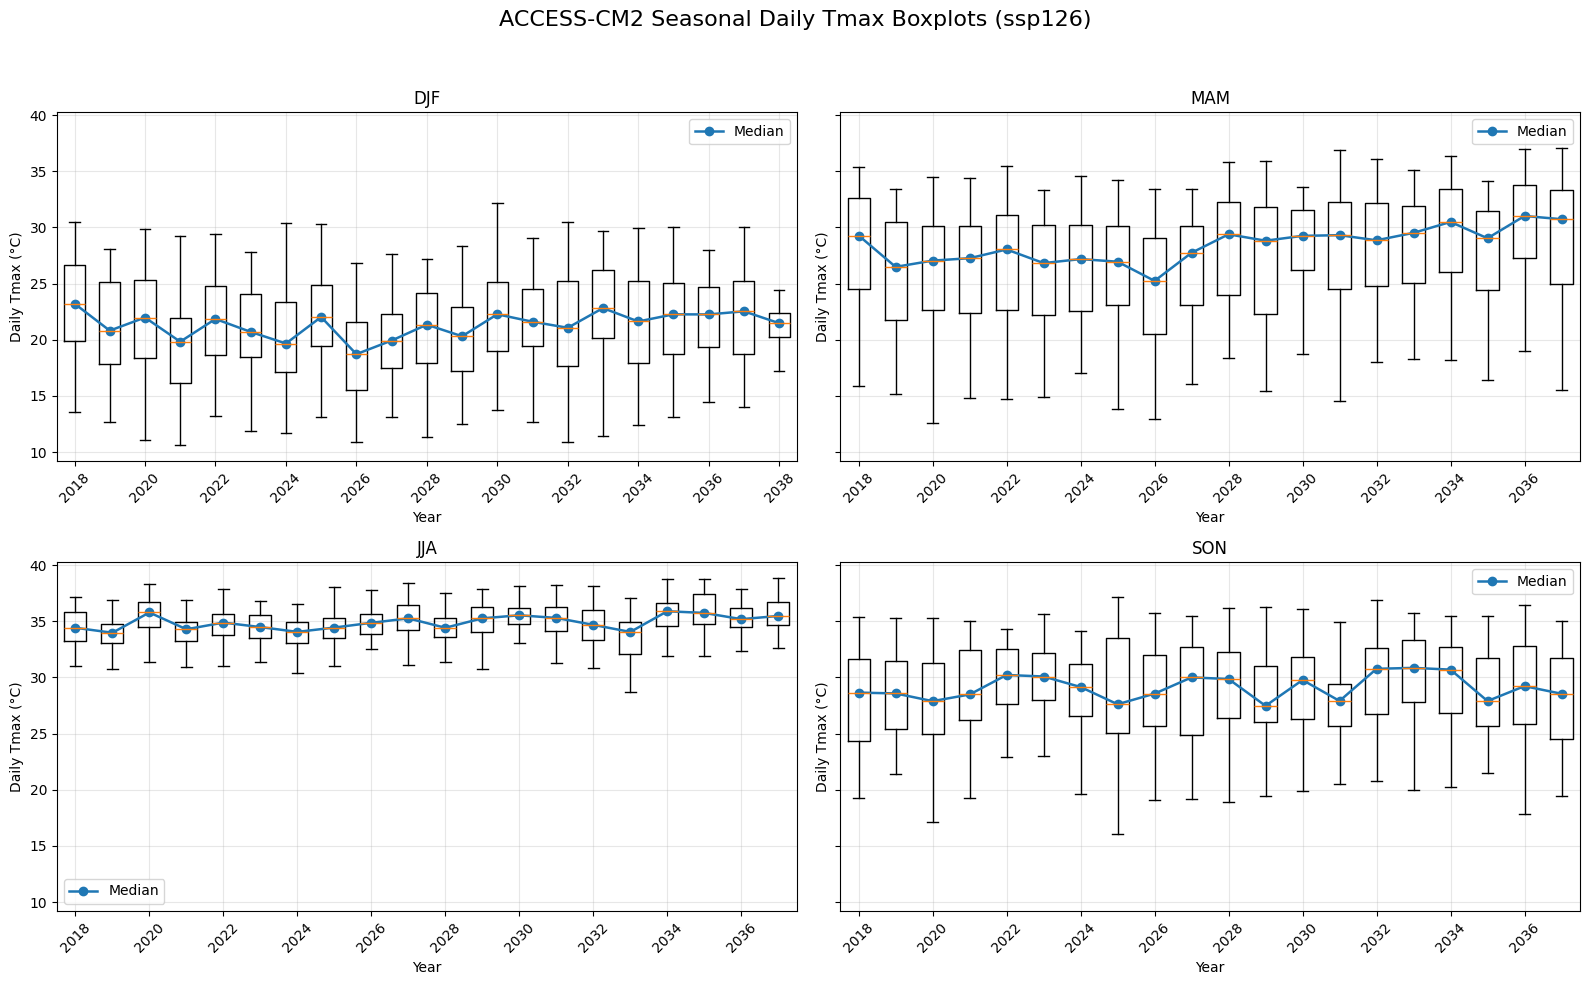

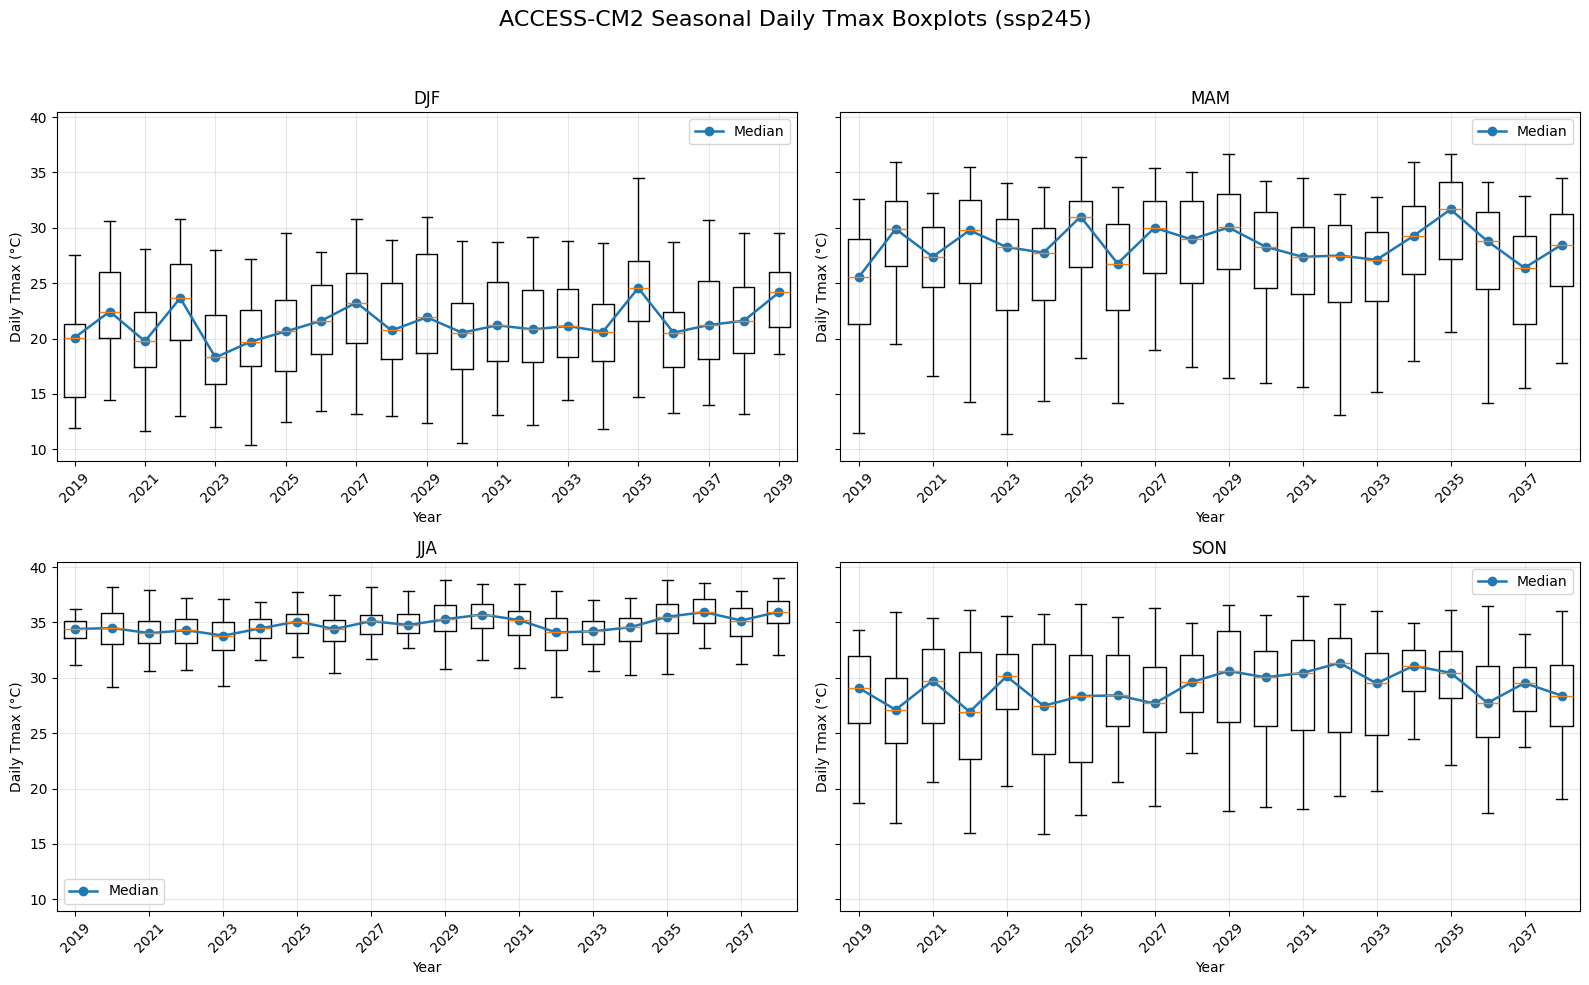

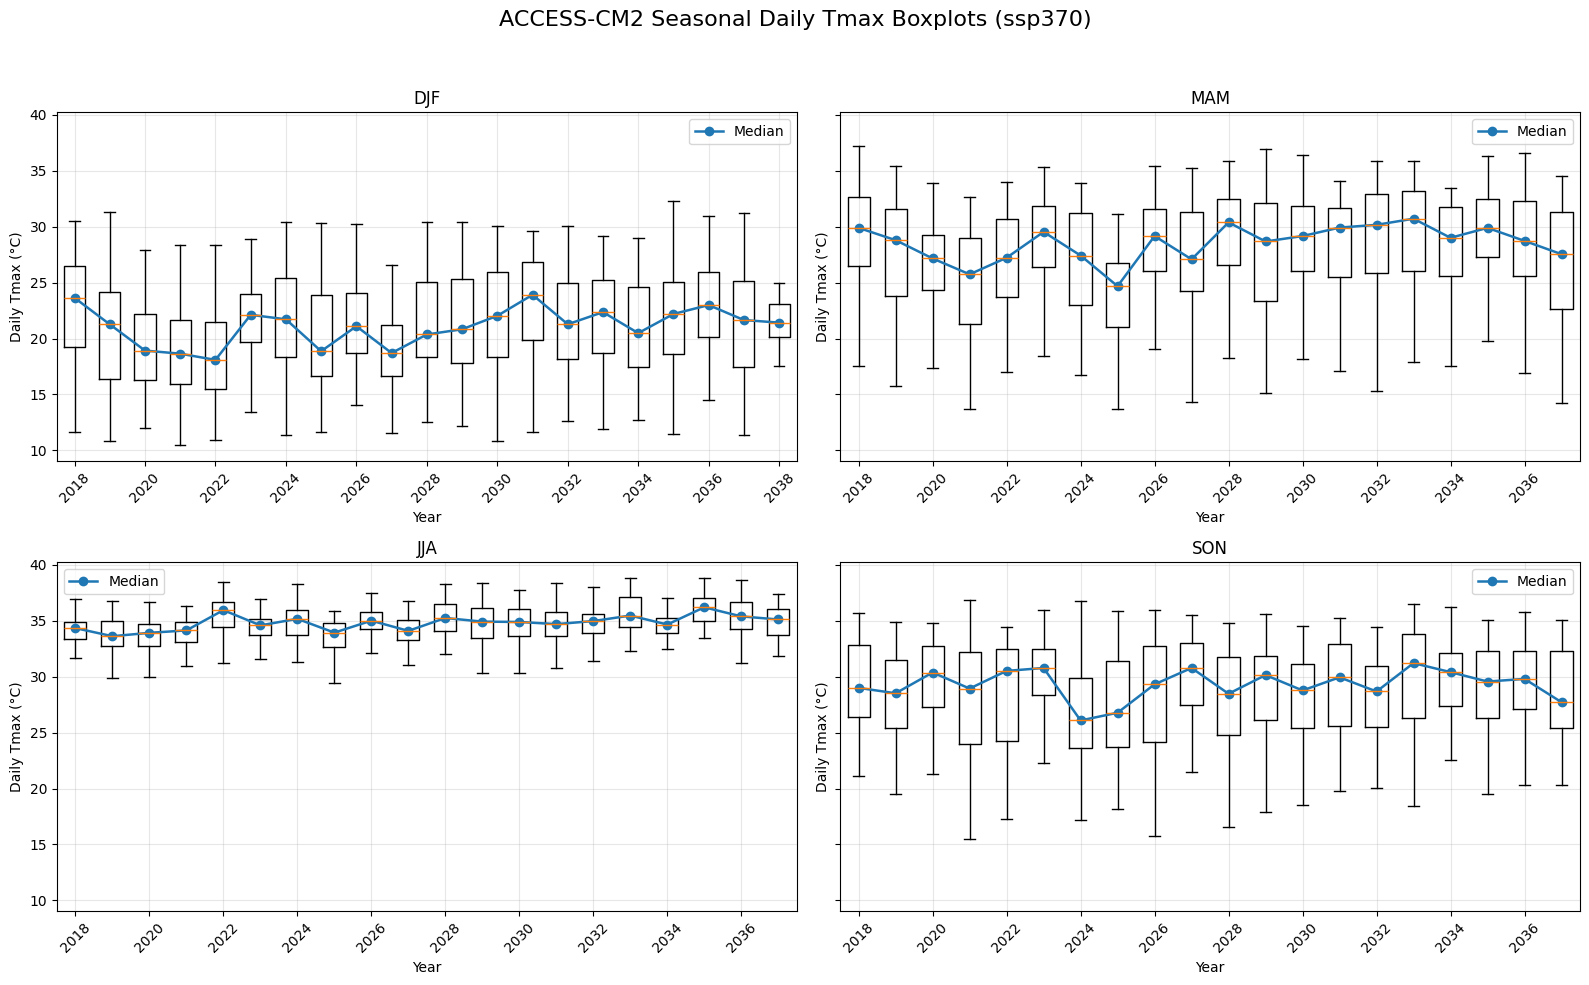

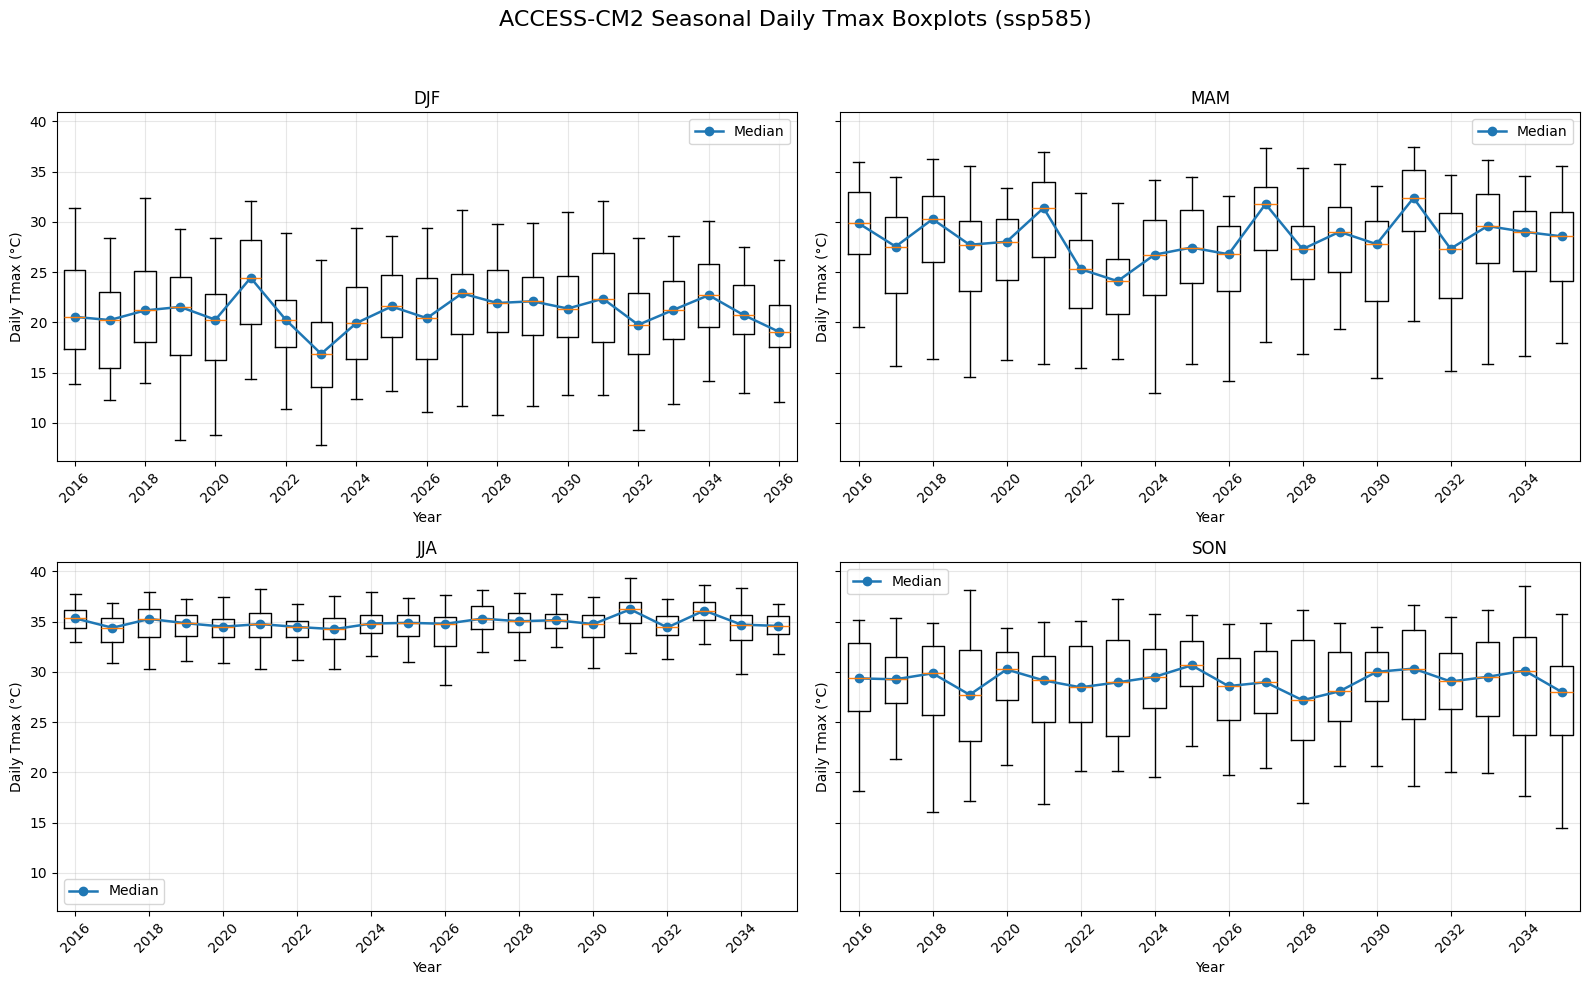

In [18]:
import matplotlib.pyplot as plt
import numpy as np

season_order = ["DJF", "MAM", "JJA", "SON"]
target_model = "ACCESS-CM2"

for ssp in ssps:
    sub_all = daily_result[
        (daily_result["ssp"] == ssp) &
        (daily_result["model"] == target_model)
    ].copy()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()

    for ax, season in zip(axes, season_order):
        sub = sub_all[sub_all["season"] == season].copy()

        years = sorted(sub["season_year"].dropna().unique())

        box_data = []
        valid_years = []
        medians = []

        for y in years:
            vals = sub.loc[sub["season_year"] == y, "tmax"].dropna().values

            if len(vals) > 0:
                box_data.append(vals)
                valid_years.append(int(y))
                medians.append(np.median(vals))

        if len(box_data) == 0:
            ax.set_title(season)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            continue

        pos = range(len(valid_years))

        ax.boxplot(
            box_data,
            positions=pos,
            widths=0.6,
            patch_artist=False,
            showfliers=False
        )

        # 加入中位數趨勢線
        ax.plot(
            pos,
            medians,
            marker="o",
            linewidth=1.8,
            label="Median"
        )

        # x 軸不要全部年份都擠在一起
        step = max(1, len(valid_years) // 8)
        tick_idx = list(range(0, len(valid_years), step))

        ax.set_xticks(tick_idx)
        ax.set_xticklabels([valid_years[i] for i in tick_idx], rotation=45)

        ax.set_title(season)
        ax.set_xlabel("Year")
        ax.set_ylabel("Daily Tmax (°C)")
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.suptitle(f"{target_model} Seasonal Daily Tmax Boxplots ({ssp})", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"{target_model} Seasonal Daily Tmax Boxplots ({ssp})", dpi=300, bbox_inches="tight")
    plt.show()

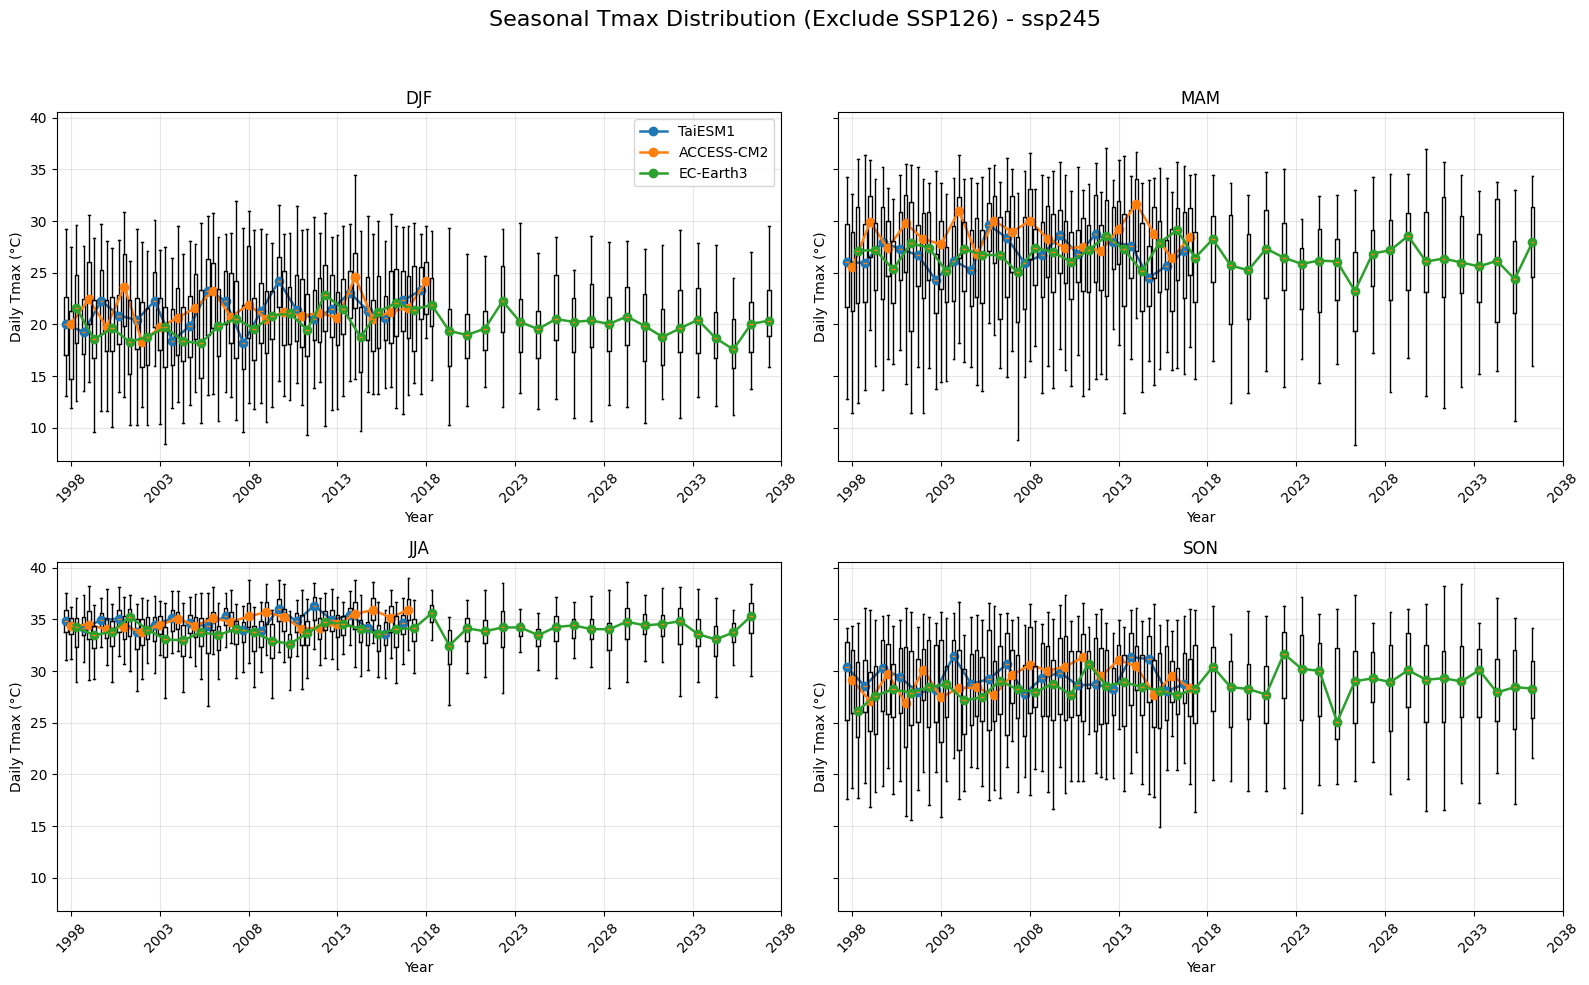

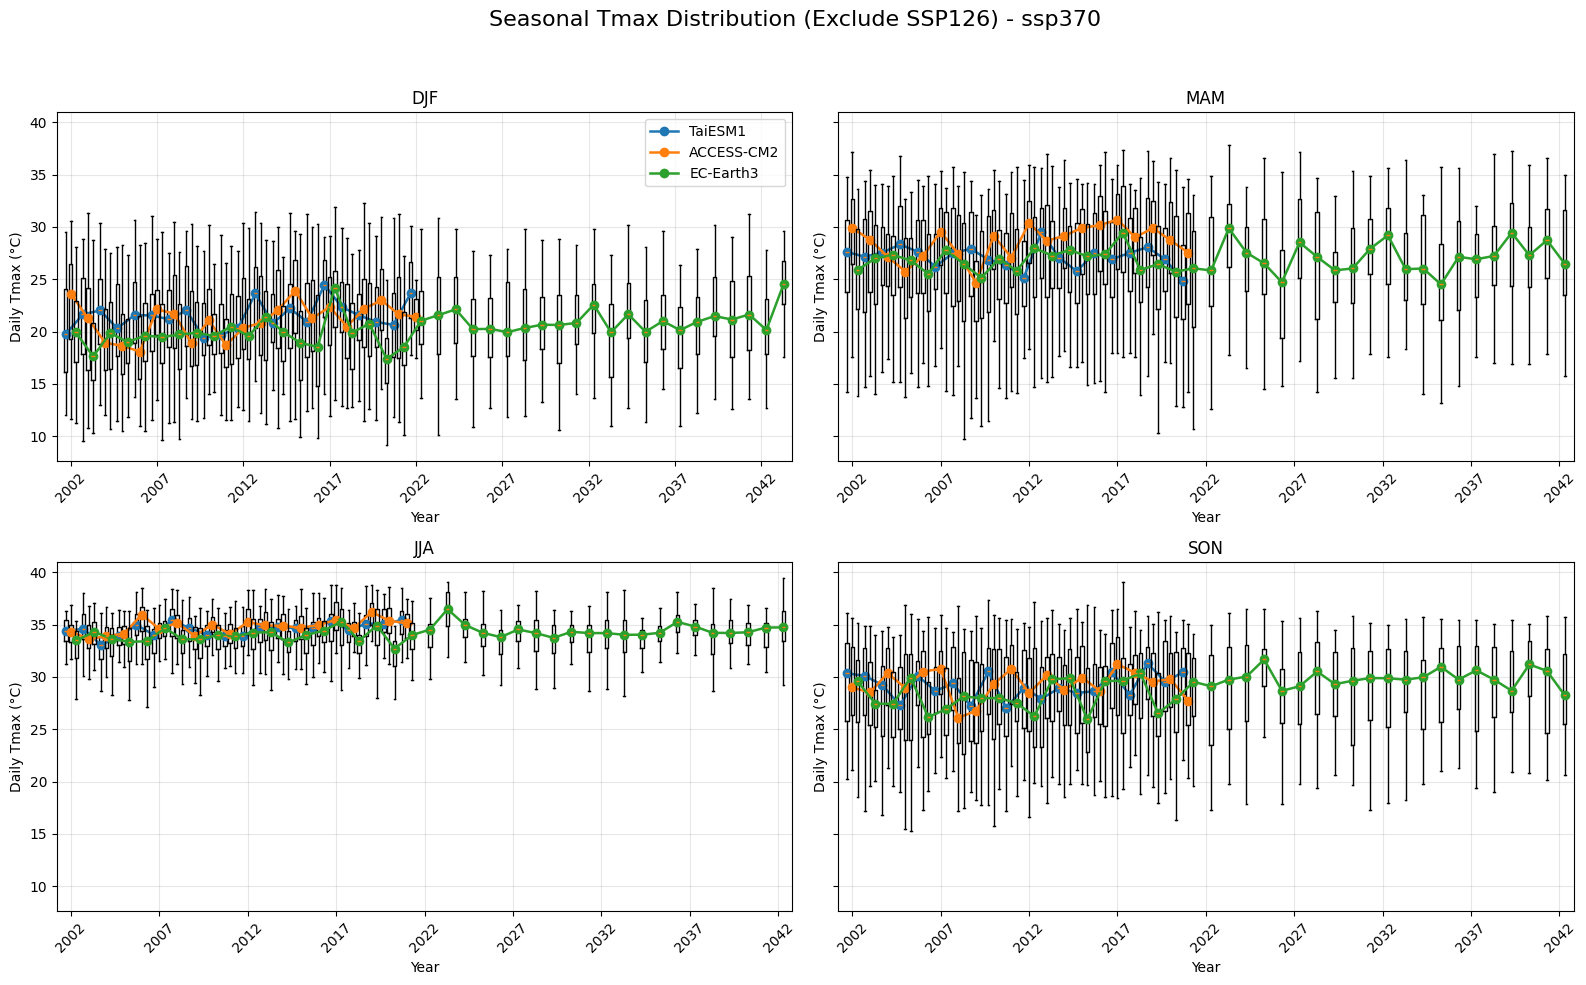

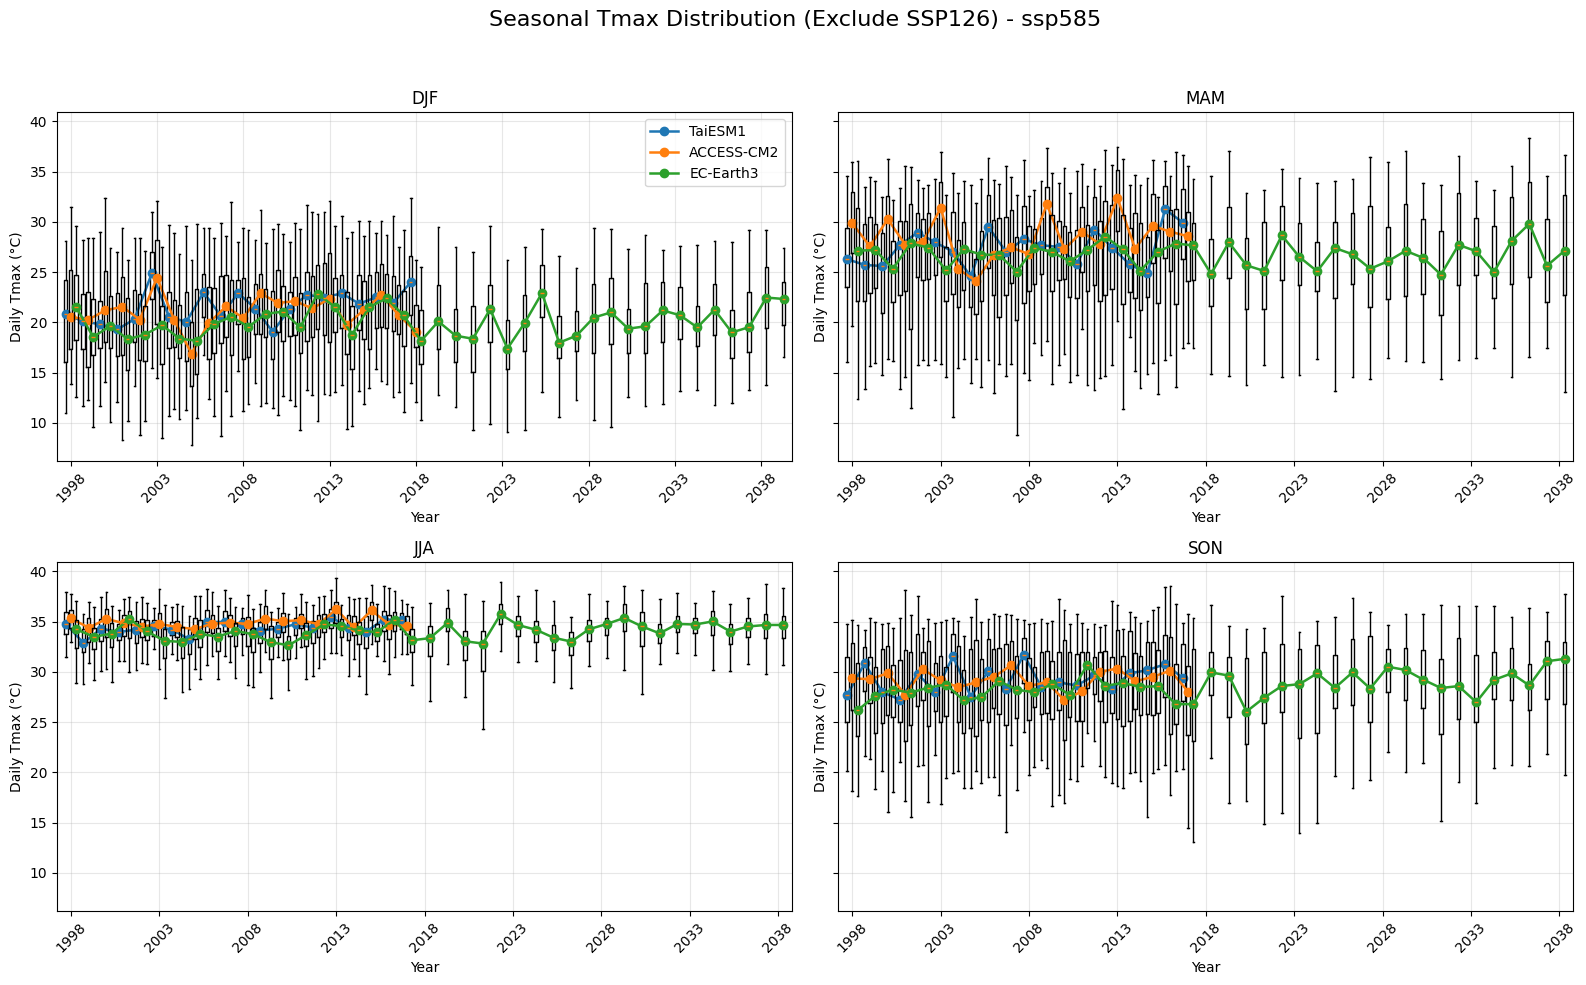

In [19]:
import matplotlib.pyplot as plt
import numpy as np

season_order = ["DJF", "MAM", "JJA", "SON"]

# ❗排除 ssp126
target_ssps = ["ssp245", "ssp370", "ssp585"]

models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]

for ssp in target_ssps:

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()

    for ax, season in zip(axes, season_order):

        sub_all = daily_result[
            (daily_result["ssp"] == ssp) &
            (daily_result["season"] == season)
        ].copy()

        years = sorted(sub_all["season_year"].dropna().unique())

        width = 0.25
        offsets = [-0.3, 0, 0.3]

        for m_idx, model in enumerate(models):

            box_data = []
            valid_years = []
            medians = []

            for y in years:
                vals = sub_all.loc[
                    (sub_all["season_year"] == y) &
                    (sub_all["model"] == model),
                    "tmax"
                ].dropna().values

                if len(vals) > 0:
                    box_data.append(vals)
                    valid_years.append(int(y))
                    medians.append(np.median(vals))

            if len(box_data) == 0:
                continue

            pos = np.arange(len(valid_years)) + offsets[m_idx]

            # 盒鬚圖
            ax.boxplot(
                box_data,
                positions=pos,
                widths=0.2,
                patch_artist=False,
                showfliers=False
            )

            # median 趨勢線
            ax.plot(
                pos,
                medians,
                marker="o",
                linewidth=1.8,
                label=model
            )

        # x 軸設定
        step = max(1, len(years) // 8)
        tick_idx = list(range(0, len(years), step))

        ax.set_xticks(tick_idx)
        ax.set_xticklabels([int(years[i]) for i in tick_idx], rotation=45)

        ax.set_title(season)
        ax.set_xlabel("Year")
        ax.set_ylabel("Daily Tmax (°C)")
        ax.grid(True, alpha=0.3)

    axes[0].legend()

    fig.suptitle(f"Seasonal Tmax Distribution (Exclude SSP126) - {ssp}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

✅ 成功讀取: TaiESM1 / ssp245
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: TaiESM1 / ssp370
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: TaiESM1 / ssp585
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: ACCESS-CM2 / ssp245
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: ACCESS-CM2 / ssp370
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: ACCESS-CM2 / ssp585
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: EC-Earth3 / ssp245
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: EC-Earth3 / ssp370
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: EC-Earth3 / ssp585
   最近格點 = lon 121.53, lat 25.02


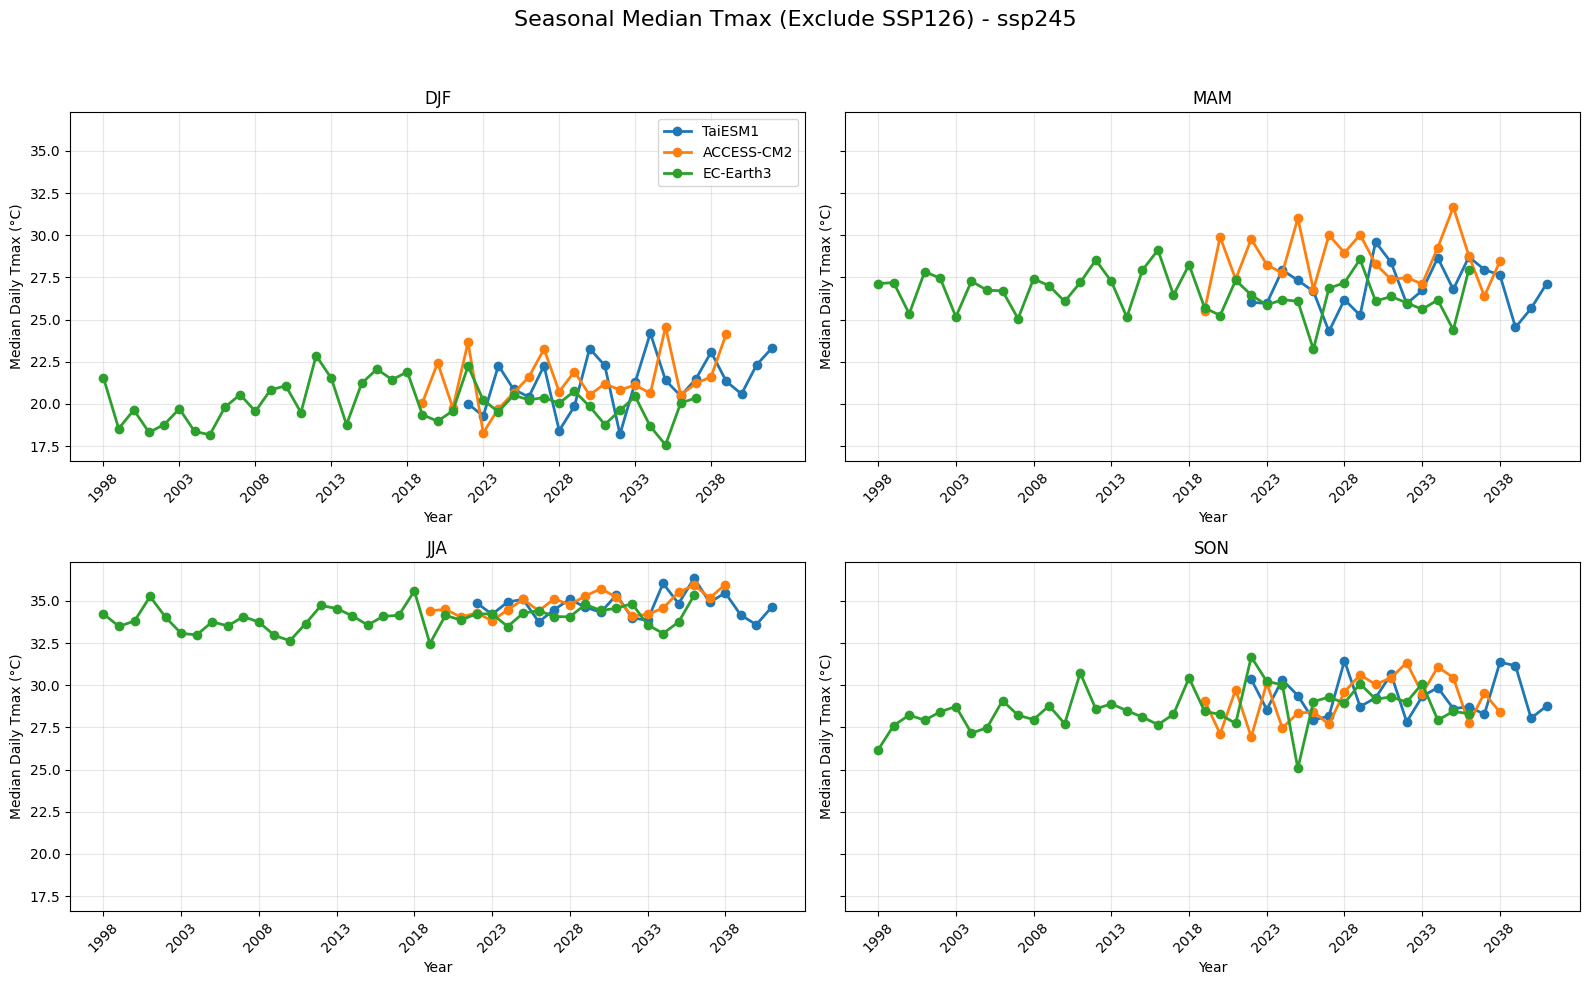

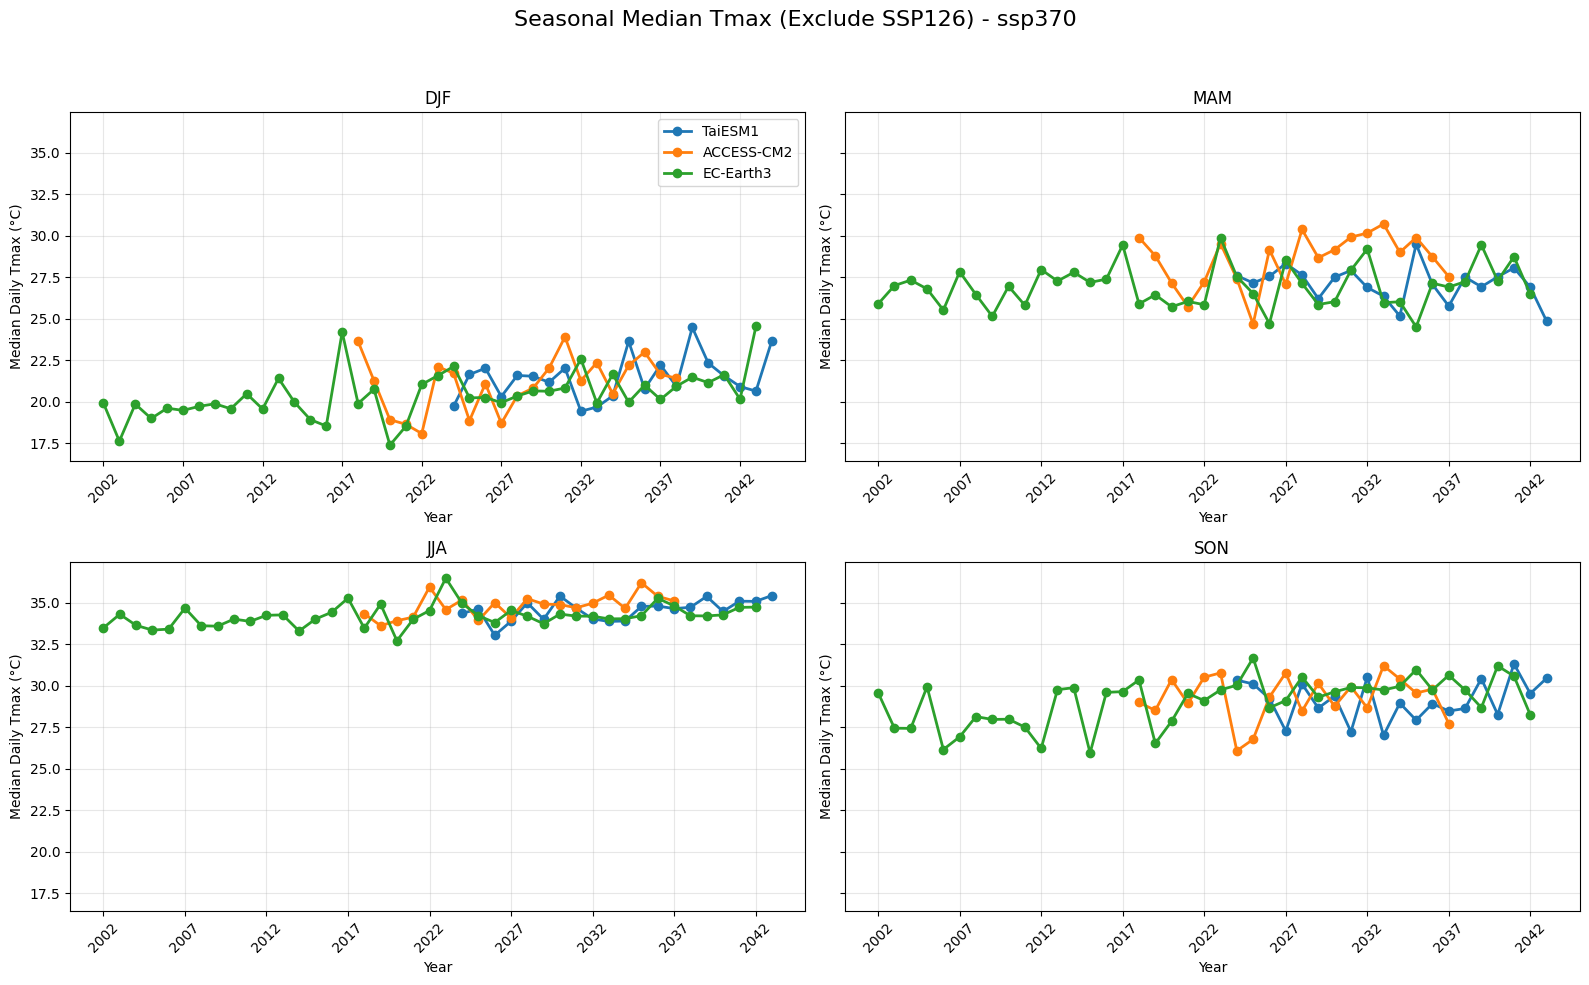

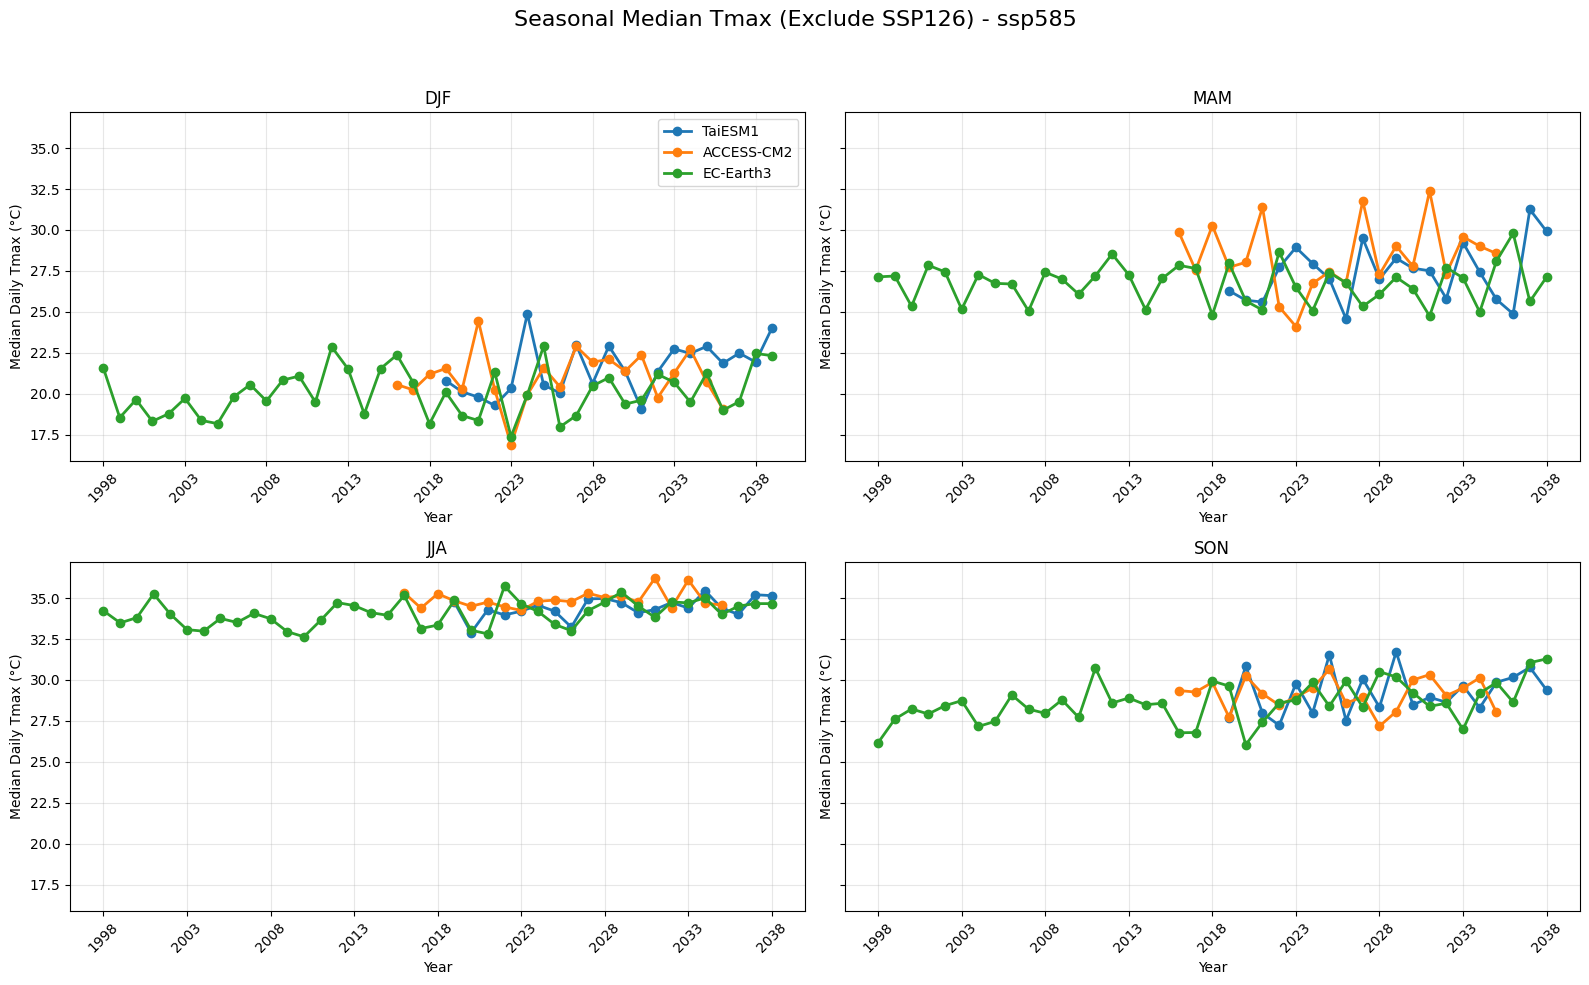

In [23]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 基本設定
# =========================
base_dir = Path("/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_最高溫/GWL1.5")

# 你要分析的模式
models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]

# 排除 ssp126
target_ssps = ["ssp245", "ssp370", "ssp585"]

# 你的目標點（大學里）
poi_lon = 121.53
poi_lat = 25.02

season_order = ["DJF", "MAM", "JJA", "SON"]


# =========================
# 2. 找檔案
# =========================
def find_csv_files_flat(base_dir, model, ssp):
    files = []
    for f in base_dir.glob("*.csv"):
        name = f.name
        if ("最高溫" in name) and (ssp in name) and (model in name):
            files.append(f)
    return sorted(files)


# =========================
# 3. 讀單一 TCCIP 格點 CSV，取最近格點
# =========================
def read_one_tccip_grid_csv(csv_path, poi_lon, poi_lat):
    df = pd.read_csv(csv_path)

    # 前兩欄通常是 lon / lat
    lon_col = df.columns[0]
    lat_col = df.columns[1]

    # 避免 PerformanceWarning：不用直接 df["dist"] = ...
    dist = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)
    nearest_idx = dist.idxmin()
    nearest = df.loc[nearest_idx].copy()

    nearest_lon = float(nearest[lon_col])
    nearest_lat = float(nearest[lat_col])

    # 第 3 欄之後都是每日資料
    value_cols = df.columns[2:]
    values = pd.to_numeric(nearest[value_cols], errors="coerce")

    # 若有缺值代碼可一併處理
    values = values.replace([-99.9, -999, -9999], np.nan)

    # 從檔名抓年份
    # 例如：AR6_統計降尺度_日資料_臺北市_最高溫_ssp585_TaiESM1_2019.csv
    year_str = csv_path.stem.split("_")[-1]
    year = int(year_str)

    # 用欄數建立日期
    dates = pd.date_range(f"{year}-01-01", periods=len(values), freq="D")

    ts = pd.DataFrame({
        "time": dates,
        "tmax": values.values
    })

    return ts, nearest_lon, nearest_lat


# =========================
# 4. 合併同一 model + ssp 的所有年份
# =========================
def read_all_years_for_model_ssp(base_dir, model, ssp, poi_lon, poi_lat):
    files = find_csv_files_flat(base_dir, model, ssp)

    if len(files) == 0:
        return None, None

    dfs = []
    nearest_info = None

    for f in files:
        try:
            ts, nearest_lon, nearest_lat = read_one_tccip_grid_csv(f, poi_lon, poi_lat)
            dfs.append(ts)

            if nearest_info is None:
                nearest_info = (nearest_lon, nearest_lat)

        except Exception as e:
            print(f"❌ 讀取失敗: {f.name} -> {e}")

    if len(dfs) == 0:
        return None, None

    combined = pd.concat(dfs, ignore_index=True)
    combined = combined.drop_duplicates(subset=["time"]).sort_values("time").reset_index(drop=True)

    return combined, nearest_info


# =========================
# 5. 建立季節資訊
# =========================
def add_season_info(df):
    df = df.copy()
    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month

    season_map = {
        12: "DJF", 1: "DJF", 2: "DJF",
        3: "MAM", 4: "MAM", 5: "MAM",
        6: "JJA", 7: "JJA", 8: "JJA",
        9: "SON", 10: "SON", 11: "SON"
    }
    df["season"] = df["month"].map(season_map)

    # DJF 的 12 月歸到下一年
    df["season_year"] = df["year"]
    df.loc[df["month"] == 12, "season_year"] += 1

    return df


# =========================
# 6. 讀所有資料
# =========================
daily_data = []

for model in models:
    for ssp in target_ssps:
        df, nearest_info = read_all_years_for_model_ssp(base_dir, model, ssp, poi_lon, poi_lat)

        if df is None or len(df) == 0:
            print(f"⚠️ 找不到資料: {model} / {ssp}")
            continue

        df = add_season_info(df)
        df["model"] = model
        df["ssp"] = ssp
        daily_data.append(df)

        print(f"✅ 成功讀取: {model} / {ssp}")
        print(f"   最近格點 = lon {nearest_info[0]:.2f}, lat {nearest_info[1]:.2f}")

if len(daily_data) == 0:
    raise ValueError("沒有成功讀到任何資料，請確認路徑、檔名和模式名稱。")

daily_result = pd.concat(daily_data, ignore_index=True)


# =========================
# 7. 畫圖：只畫 median，x 軸用真正年份
# =========================
for ssp in target_ssps:

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()

    for ax, season in zip(axes, season_order):

        sub_all = daily_result[
            (daily_result["ssp"] == ssp) &
            (daily_result["season"] == season)
        ].copy()

        for model in models:
            sub_model = sub_all[sub_all["model"] == model].copy()

            if sub_model.empty:
                continue

            years = sorted(sub_model["season_year"].dropna().unique())

            medians = []
            valid_years = []

            for y in years:
                vals = sub_model.loc[sub_model["season_year"] == y, "tmax"].dropna().values

                if len(vals) > 0:
                    medians.append(np.median(vals))
                    valid_years.append(int(y))

            if len(medians) == 0:
                continue

            # ✅ 直接用真正年份當 x 軸
            ax.plot(
                valid_years,
                medians,
                marker="o",
                linewidth=2,
                label=model
            )

            # 每個 model 可用自己的年份，不強迫全部對齊

        # x 軸刻度：從這個 season + ssp 下的所有年份取代表值
        all_years = sorted(sub_all["season_year"].dropna().astype(int).unique())
        if len(all_years) > 0:
            step = max(1, len(all_years) // 8)
            tick_years = all_years[::step]
            ax.set_xticks(tick_years)
            ax.set_xticklabels(tick_years, rotation=45)

        ax.set_title(season)
        ax.set_xlabel("Year")
        ax.set_ylabel("Median Daily Tmax (°C)")
        ax.grid(True, alpha=0.3)

    axes[0].legend()
    fig.suptitle(f"Seasonal Median Tmax (Exclude SSP126) - {ssp}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"Seasonal Median Tmax (Exclude SSP126) - {ssp}", dpi=300, bbox_inches="tight")
    plt.show()

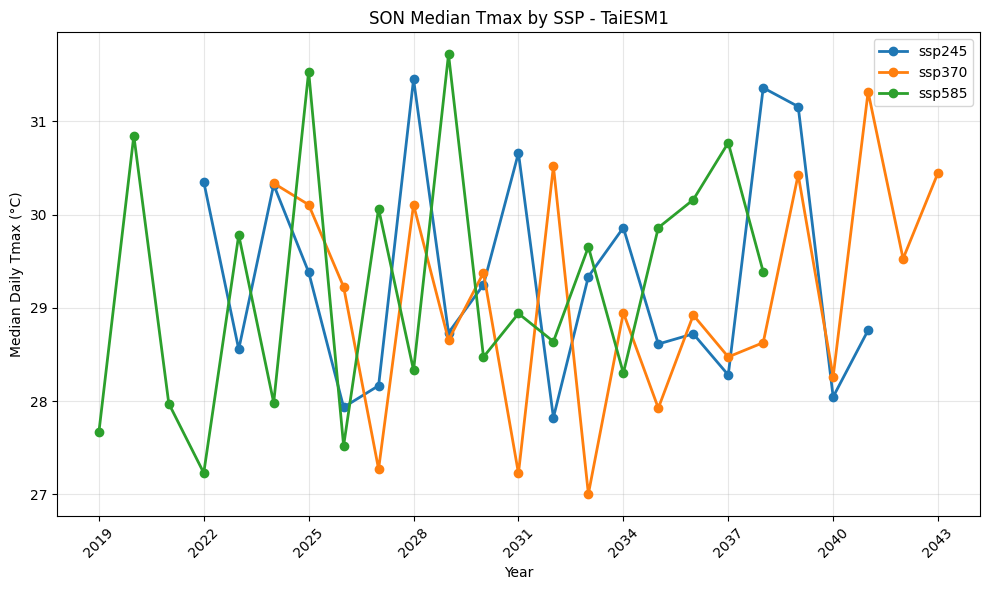

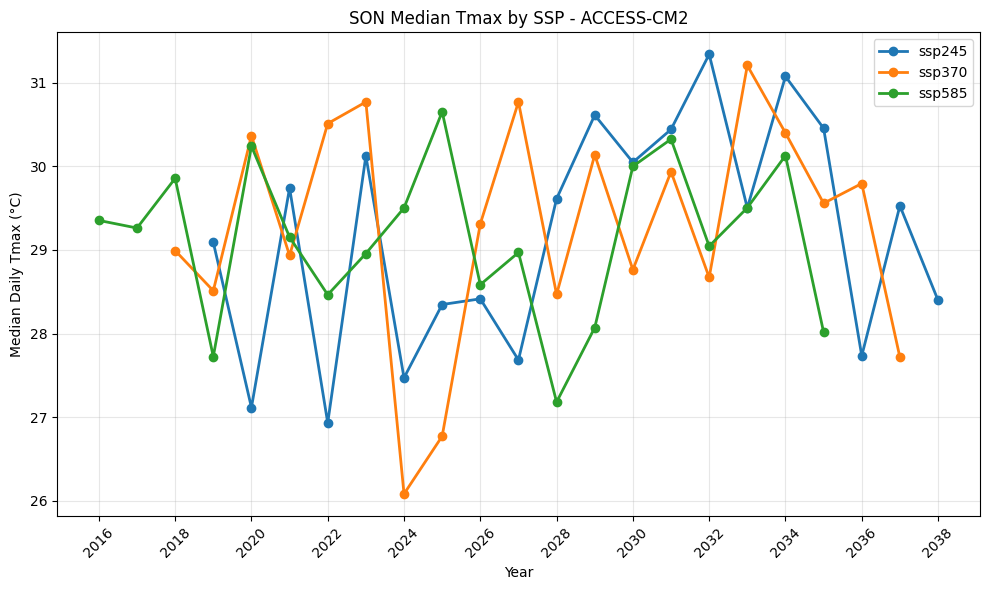

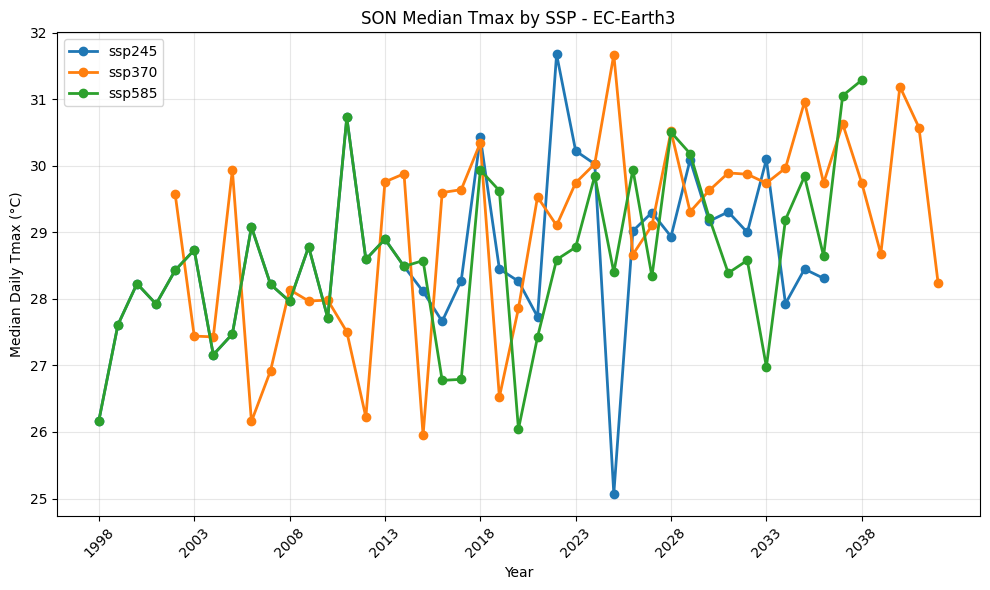

In [27]:
import matplotlib.pyplot as plt
import numpy as np

target_season = "SON"
target_ssps = ["ssp245", "ssp370", "ssp585"]
models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]

#    season_map = {
      #  12: "DJF", 1: "DJF", 2: "DJF",
    #    3: "MAM", 4: "MAM", 5: "MAM",
    #    6: "JJA", 7: "JJA", 8: "JJA",
    #    9: "SON", 10: "SON", 11: "SON"
   # }


for model in models:
    plt.figure(figsize=(10, 6))

    sub_all = daily_result[
        (daily_result["model"] == model) &
        (daily_result["season"] == target_season) &
        (daily_result["ssp"].isin(target_ssps))
    ].copy()

    for ssp in target_ssps:
        sub_ssp = sub_all[sub_all["ssp"] == ssp].copy()

        if sub_ssp.empty:
            continue

        years = sorted(sub_ssp["season_year"].dropna().astype(int).unique())

        medians = []
        valid_years = []

        for y in years:
            vals = sub_ssp.loc[sub_ssp["season_year"] == y, "tmax"].dropna().values
            if len(vals) > 0:
                medians.append(np.median(vals))
                valid_years.append(int(y))

        plt.plot(valid_years, medians, marker="o", linewidth=2, label=ssp)

    if len(sub_all) > 0:
        all_years = sorted(sub_all["season_year"].dropna().astype(int).unique())
        step = max(1, len(all_years) // 8)
        tick_years = all_years[::step]
        plt.xticks(tick_years, tick_years, rotation=45)

    plt.title(f"{target_season} Median Tmax by SSP - {model}")
    plt.xlabel("Year")
    plt.ylabel("Median Daily Tmax (°C)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{target_season} Median Tmax by SSP - {model}", dpi=300, bbox_inches="tight")
    plt.show()

In [29]:
def read_one_tccip_grid_csv(csv_path, poi_lon, poi_lat):
    df = pd.read_csv(csv_path)

    lon_col = df.columns[0]
    lat_col = df.columns[1]

    dist = np.sqrt((df[lon_col] - poi_lon)**2 + (df[lat_col] - poi_lat)**2)
    nearest_idx = dist.idxmin()
    nearest = df.loc[nearest_idx].copy()

    nearest_lon = float(nearest[lon_col])
    nearest_lat = float(nearest[lat_col])

    value_cols = df.columns[2:]
    values = pd.to_numeric(nearest[value_cols], errors="coerce").replace([-99.9, -999, -9999], np.nan)

    year = int(csv_path.stem.split("_")[-1])
    dates = pd.date_range(f"{year}-01-01", periods=len(values), freq="D")

    ts = pd.DataFrame({
        "time": dates,
        "tmax": values.values
    })

    return ts, nearest_lon, nearest_lat

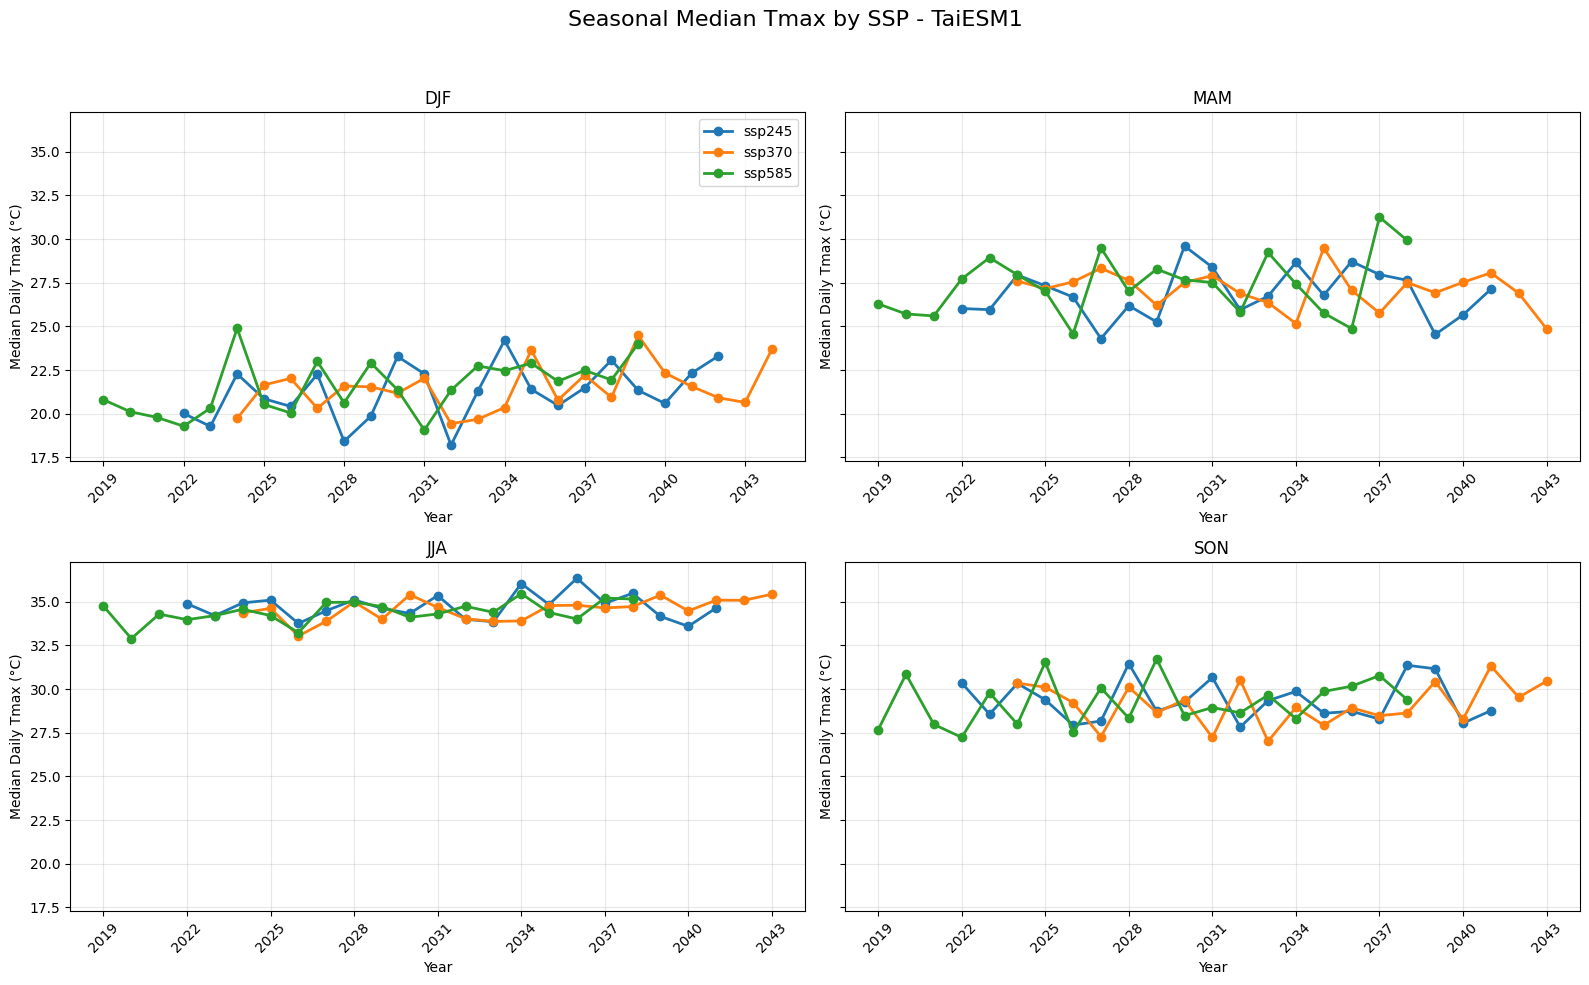

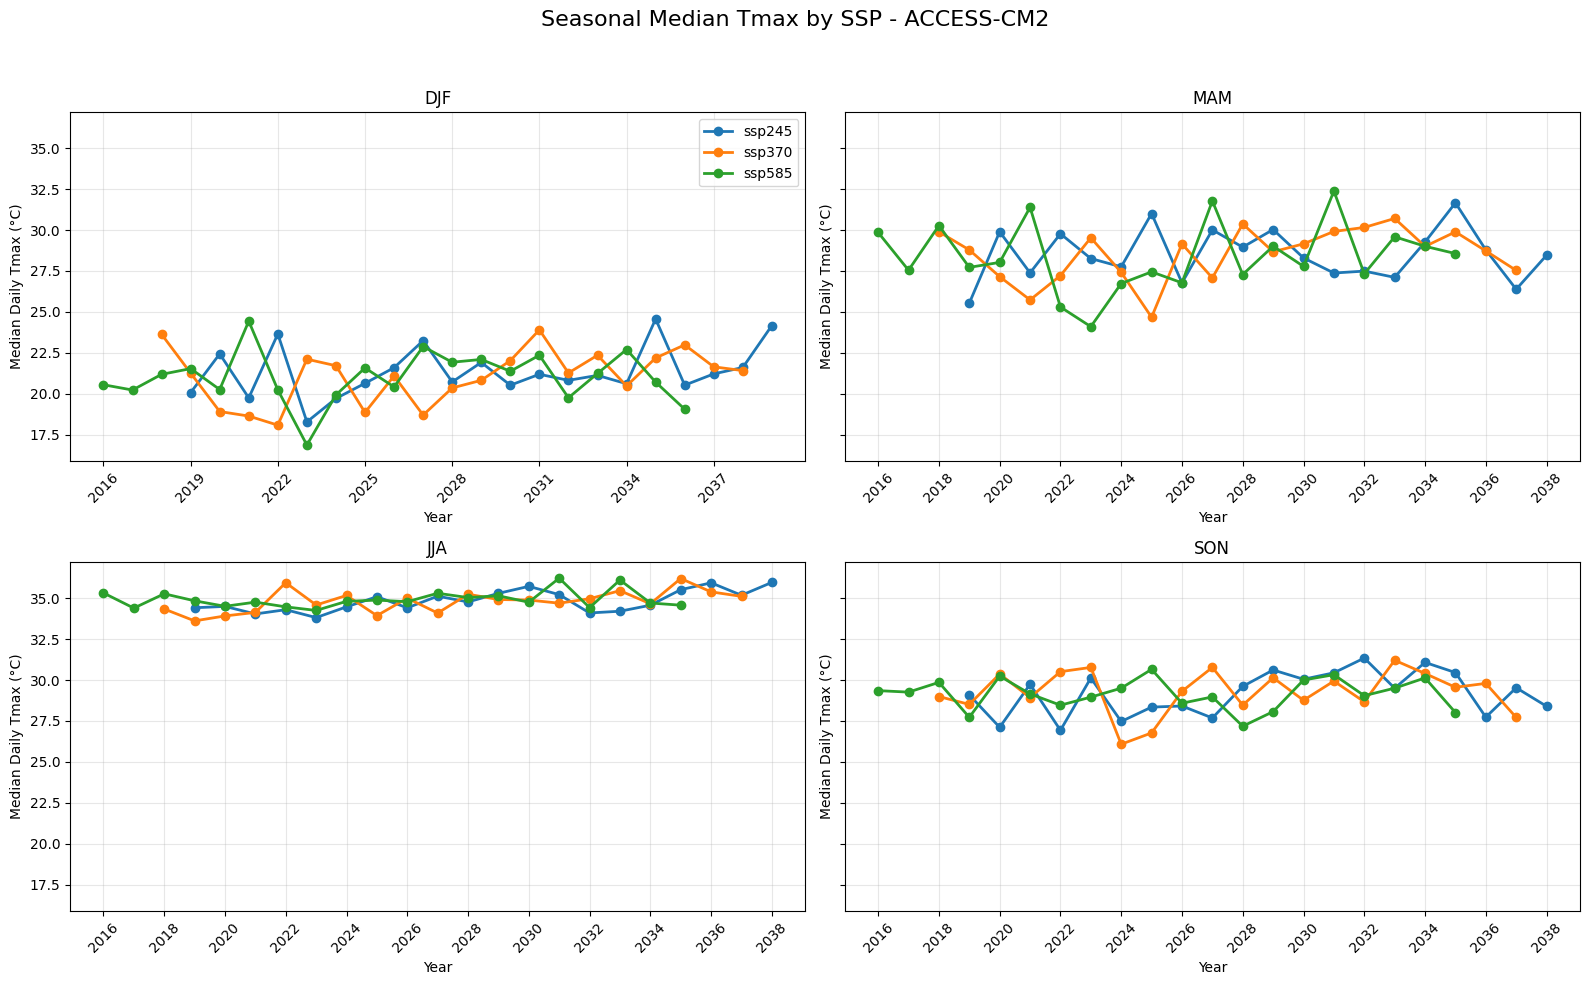

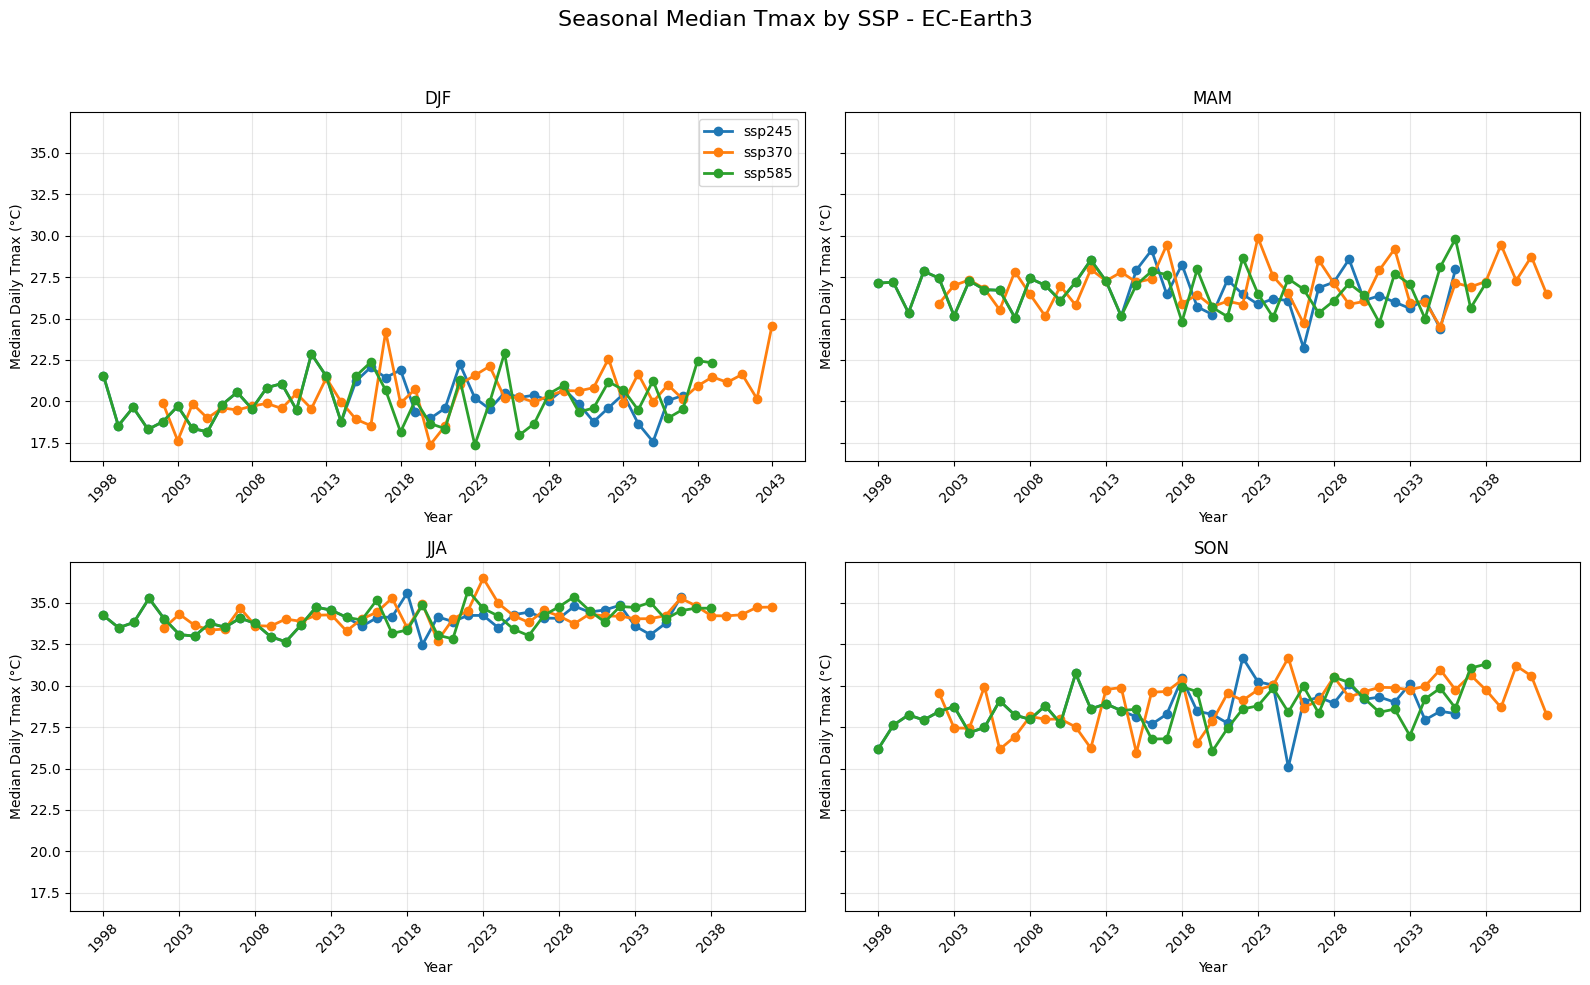

In [32]:
import matplotlib.pyplot as plt
import numpy as np

season_order = ["DJF", "MAM", "JJA", "SON"]
target_ssps = ["ssp245", "ssp370", "ssp585"]
models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]

output_dir = Path("/Users/stevechiao/Climate_project/程式作業/Daxue＿village/figue")
output_dir.mkdir(parents=True, exist_ok=True)

for model in models:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()

    for ax, season in zip(axes, season_order):
        sub_all = daily_result[
            (daily_result["model"] == model) &
            (daily_result["season"] == season) &
            (daily_result["ssp"].isin(target_ssps))
        ].copy()

        for ssp in target_ssps:
            sub_ssp = sub_all[sub_all["ssp"] == ssp].copy()

            if sub_ssp.empty:
                continue

            years = sorted(sub_ssp["season_year"].dropna().astype(int).unique())

            medians = []
            valid_years = []

            for y in years:
                vals = sub_ssp.loc[sub_ssp["season_year"] == y, "tmax"].dropna().values
                if len(vals) > 0:
                    medians.append(np.median(vals))
                    valid_years.append(int(y))

            if len(medians) == 0:
                continue

            ax.plot(
                valid_years,
                medians,
                marker="o",
                linewidth=2,
                label=ssp
            )

        all_years = sorted(sub_all["season_year"].dropna().astype(int).unique())
        if len(all_years) > 0:
            step = max(1, len(all_years) // 8)
            tick_years = all_years[::step]
            ax.set_xticks(tick_years)
            ax.set_xticklabels(tick_years, rotation=45)

        ax.set_title(season)
        ax.set_xlabel("Year")
        ax.set_ylabel("Median Daily Tmax (°C)")
        ax.grid(True, alpha=0.3)

    axes[0].legend()
    fig.suptitle(f"Seasonal Median Tmax by SSP - {model}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    #plt.savefig(f"Seasonal_Median_Tmax_by_SSP_{model}.png", dpi=300, bbox_inches="tight")
    filename = f"Seasonal_Median_Tmax_by_SSP_{model}.png"
    plt.savefig(output_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()

✅ 成功讀取: TaiESM1 / ssp245
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: TaiESM1 / ssp370
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: TaiESM1 / ssp585
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: ACCESS-CM2 / ssp245
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: ACCESS-CM2 / ssp370
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: ACCESS-CM2 / ssp585
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: EC-Earth3 / ssp245
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: EC-Earth3 / ssp370
   最近格點 = lon 121.53, lat 25.02
✅ 成功讀取: EC-Earth3 / ssp585
   最近格點 = lon 121.53, lat 25.02


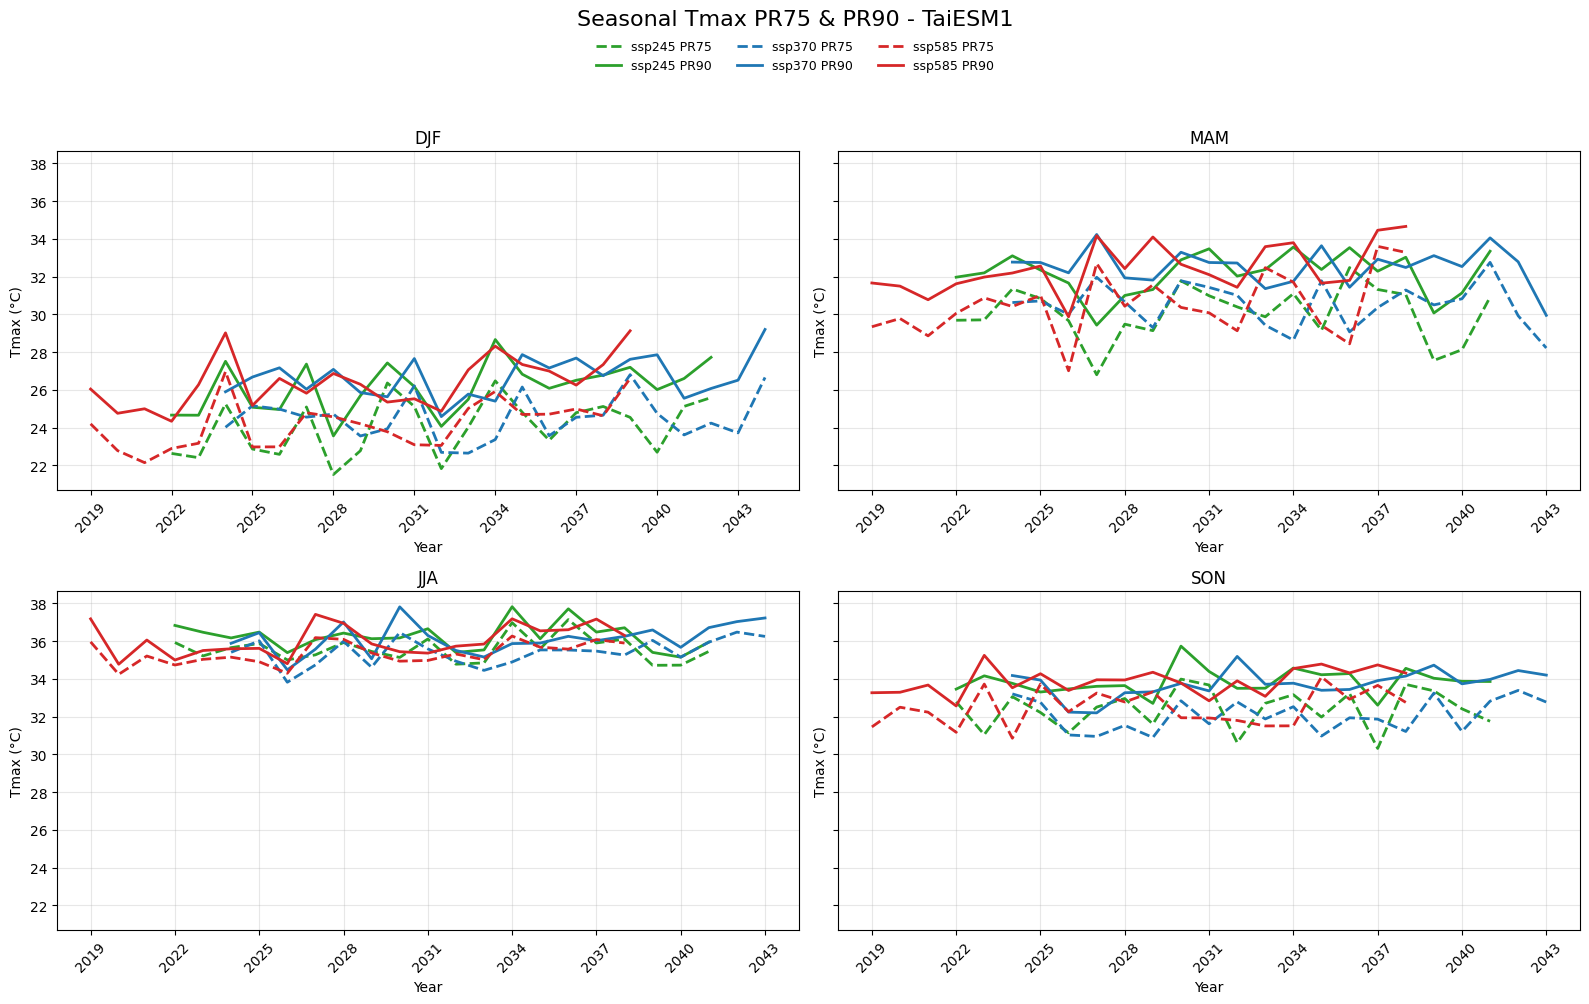

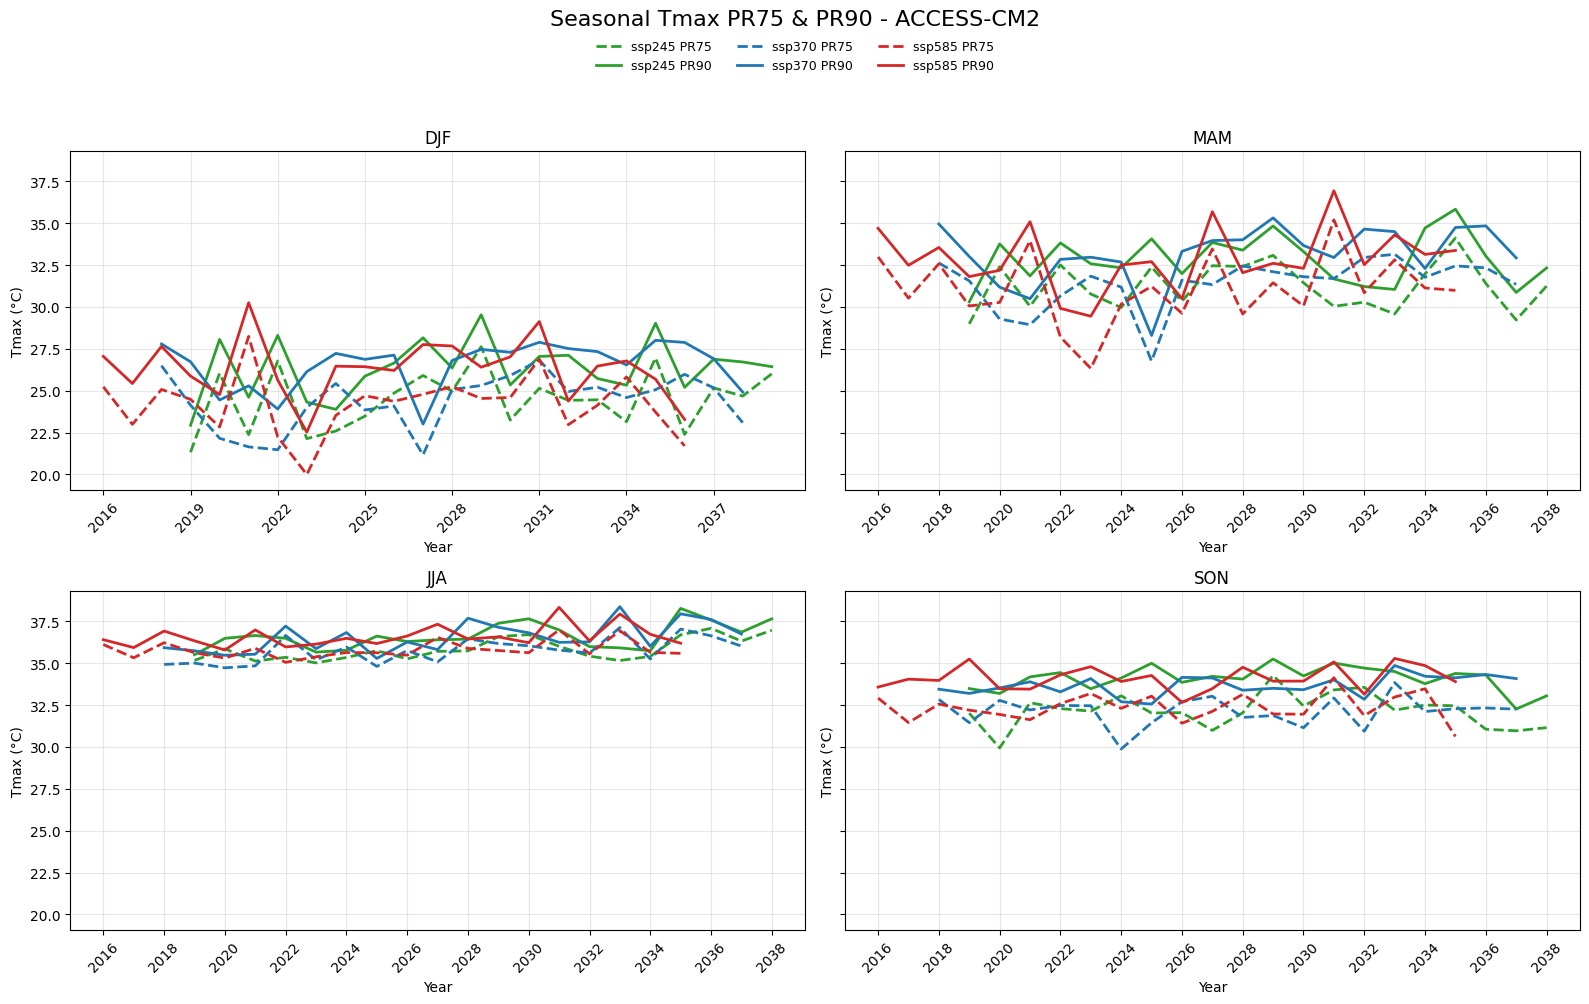

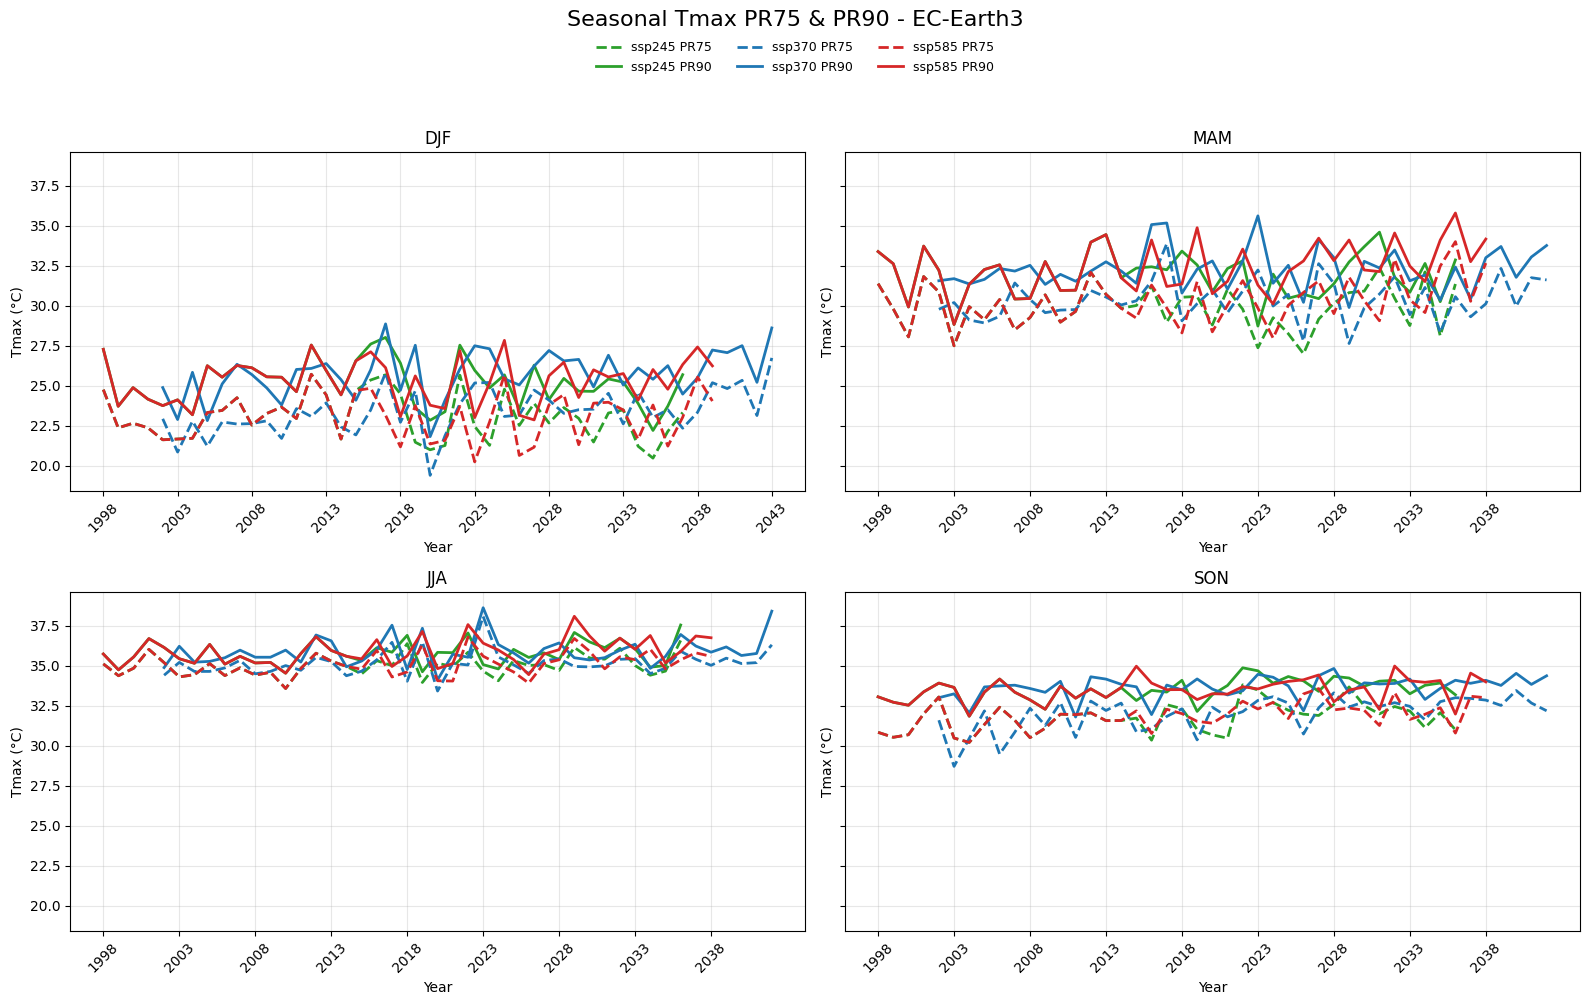

In [38]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. 基本設定
# =========================================
base_dir = Path("/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_最高溫/GWL1.5")
output_dir = Path("/Users/stevechiao/Climate_project/程式作業/Daxue＿village/figue")
output_dir.mkdir(parents=True, exist_ok=True)

models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
target_ssps = ["ssp245", "ssp370", "ssp585"]
season_order = ["DJF", "MAM", "JJA", "SON"]

# 大學里座標
poi_lon = 121.53
poi_lat = 25.02

# 同一 SSP 用同一顏色
color_map = {
    "ssp245": "tab:green",
    "ssp370": "tab:blue",
    "ssp585": "tab:red"
}


# =========================================
# 2. 找檔案
# =========================================
def find_csv_files_flat(base_dir, model, ssp):
    files = []
    for f in base_dir.glob("*.csv"):
        name = f.name
        if ("最高溫" in name) and (ssp in name) and (model in name):
            files.append(f)
    return sorted(files)


# =========================================
# 3. 讀單一 CSV，取最近格點
#    修正 PerformanceWarning：不再寫 df["dist"]
# =========================================
def read_one_tccip_grid_csv(csv_path, poi_lon, poi_lat):
    df = pd.read_csv(csv_path)

    lon_col = df.columns[0]
    lat_col = df.columns[1]

    lon_vals = pd.to_numeric(df[lon_col], errors="coerce")
    lat_vals = pd.to_numeric(df[lat_col], errors="coerce")

    dist = np.sqrt((lon_vals - poi_lon) ** 2 + (lat_vals - poi_lat) ** 2)
    nearest_idx = dist.idxmin()
    nearest = df.loc[nearest_idx].copy()

    nearest_lon = float(nearest[lon_col])
    nearest_lat = float(nearest[lat_col])

    # 第3欄之後是每日資料
    value_cols = df.columns[2:]
    values = pd.to_numeric(nearest[value_cols], errors="coerce")
    values = values.replace([-99.9, -999, -9999], np.nan)

    # 從檔名抓年份
    # 例如：AR6_統計降尺度_日資料_臺北市_最高溫_ssp585_TaiESM1_2019.csv
    year = int(csv_path.stem.split("_")[-1])

    dates = pd.date_range(f"{year}-01-01", periods=len(values), freq="D")

    ts = pd.DataFrame({
        "time": dates,
        "tmax": values.values
    })

    return ts, nearest_lon, nearest_lat


# =========================================
# 4. 合併同一 model + ssp 的所有年份
# =========================================
def read_all_years_for_model_ssp(base_dir, model, ssp, poi_lon, poi_lat):
    files = find_csv_files_flat(base_dir, model, ssp)

    if len(files) == 0:
        return None, None

    dfs = []
    nearest_info = None

    for f in files:
        try:
            ts, nearest_lon, nearest_lat = read_one_tccip_grid_csv(f, poi_lon, poi_lat)
            dfs.append(ts)

            if nearest_info is None:
                nearest_info = (nearest_lon, nearest_lat)

        except Exception as e:
            print(f"❌ 讀取失敗: {f.name} -> {e}")

    if len(dfs) == 0:
        return None, None

    combined = pd.concat(dfs, ignore_index=True)
    combined = combined.drop_duplicates(subset=["time"]).sort_values("time").reset_index(drop=True)

    return combined, nearest_info


# =========================================
# 5. 建立季節欄位
# =========================================
def add_season_info(df):
    df = df.copy()
    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month

    season_map = {
        12: "DJF", 1: "DJF", 2: "DJF",
        3: "MAM", 4: "MAM", 5: "MAM",
        6: "JJA", 7: "JJA", 8: "JJA",
        9: "SON", 10: "SON", 11: "SON"
    }
    df["season"] = df["month"].map(season_map)

    # 12月歸到下一年的 DJF
    df["season_year"] = df["year"]
    df.loc[df["month"] == 12, "season_year"] += 1

    return df


# =========================================
# 6. 讀所有資料，建立 daily_result
# =========================================
daily_data = []

for model in models:
    for ssp in target_ssps:
        df, nearest_info = read_all_years_for_model_ssp(
            base_dir=base_dir,
            model=model,
            ssp=ssp,
            poi_lon=poi_lon,
            poi_lat=poi_lat
        )

        if df is None or len(df) == 0:
            print(f"⚠️ 找不到資料: {model} / {ssp}")
            continue

        df = add_season_info(df)
        df["model"] = model
        df["ssp"] = ssp
        daily_data.append(df)

        print(f"✅ 成功讀取: {model} / {ssp}")
        print(f"   最近格點 = lon {nearest_info[0]:.2f}, lat {nearest_info[1]:.2f}")

if len(daily_data) == 0:
    raise ValueError("沒有成功讀到任何資料，請檢查路徑、檔名與模式名稱。")

daily_result = pd.concat(daily_data, ignore_index=True)


# =========================================
# 7. 畫圖：每個模式一張圖
#    同一 SSP 同色
#    PR75 虛線 / PR90 實線
# =========================================
for model in models:

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()

    for ax, season in zip(axes, season_order):

        sub_all = daily_result[
            (daily_result["model"] == model) &
            (daily_result["season"] == season) &
            (daily_result["ssp"].isin(target_ssps))
        ].copy()

        for ssp in target_ssps:
            sub_ssp = sub_all[sub_all["ssp"] == ssp].copy()

            if sub_ssp.empty:
                continue

            years = sorted(sub_ssp["season_year"].dropna().astype(int).unique())

            pr75_list = []
            pr90_list = []
            valid_years = []

            for y in years:
                vals = sub_ssp.loc[
                    sub_ssp["season_year"] == y, "tmax"
                ].dropna().values

                if len(vals) > 0:
                    pr75_list.append(np.percentile(vals, 75))
                    pr90_list.append(np.percentile(vals, 90))
                    valid_years.append(int(y))

            if len(valid_years) == 0:
                continue

            color = color_map[ssp]

            # PR75：虛線
            ax.plot(
                valid_years,
                pr75_list,
                linestyle="--",
                linewidth=2,
                color=color,
                label=f"{ssp} PR75"
            )

            # PR90：實線
            ax.plot(
                valid_years,
                pr90_list,
                linestyle="-",
                linewidth=2,
                color=color,
                label=f"{ssp} PR90"
            )

        all_years = sorted(sub_all["season_year"].dropna().astype(int).unique())
        if len(all_years) > 0:
            step = max(1, len(all_years) // 8)
            tick_years = all_years[::step]
            ax.set_xticks(tick_years)
            ax.set_xticklabels(tick_years, rotation=45)

        ax.set_title(season)
        ax.set_xlabel("Year")
        ax.set_ylabel("Tmax (°C)")
        ax.grid(True, alpha=0.3)

    # 只抓第一個子圖的 legend handles
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),  # ⬅️ legend 往上推
        ncol=3,
        fontsize=9,
        frameon=False
    )

    fig.suptitle(
        f"Seasonal Tmax PR75 & PR90 - {model}",
        fontsize=16,
        y=1   # ⬅️ 標題往下壓一點
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])  # ⬅️ 留空間給 legend

    filename = f"Seasonal_Tmax_PR75_PR90_{model}.png"
    plt.savefig(output_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()

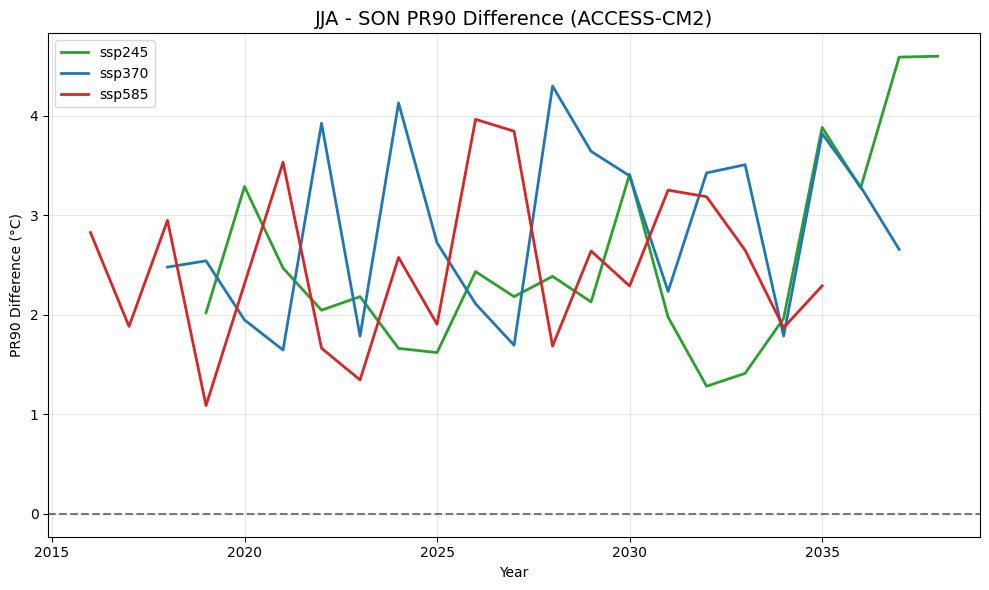

In [39]:
import matplotlib.pyplot as plt
import numpy as np

season_pair = ["JJA", "SON"]
target_model = "ACCESS-CM2"

color_map = {
    "ssp245": "tab:green",
    "ssp370": "tab:blue",
    "ssp585": "tab:red"
}

plt.figure(figsize=(10,6))

for ssp in target_ssps:

    sub = daily_result[
        (daily_result["model"] == target_model) &
        (daily_result["ssp"] == ssp) &
        (daily_result["season"].isin(season_pair))
    ].copy()

    years = sorted(sub["season_year"].dropna().astype(int).unique())

    diff_list = []
    valid_years = []

    for y in years:

        pr90_dict = {}

        for season in season_pair:
            vals = sub.loc[
                (sub["season_year"] == y) &
                (sub["season"] == season),
                "tmax"
            ].dropna().values

            if len(vals) > 0:
                pr90_dict[season] = np.percentile(vals, 90)

        # 必須兩季都有才計算
        if len(pr90_dict) == 2:
            diff = pr90_dict["JJA"] - pr90_dict["SON"]
            diff_list.append(diff)
            valid_years.append(y)

    if len(valid_years) == 0:
        continue

    plt.plot(
        valid_years,
        diff_list,
        linewidth=2,
        color=color_map[ssp],
        label=ssp
    )

# 畫0線（超重要）
plt.axhline(0, linestyle="--", color="black", alpha=0.5)

plt.title(f"JJA - SON PR90 Difference ({target_model})", fontsize=14)
plt.xlabel("Year")
plt.ylabel("PR90 Difference (°C)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

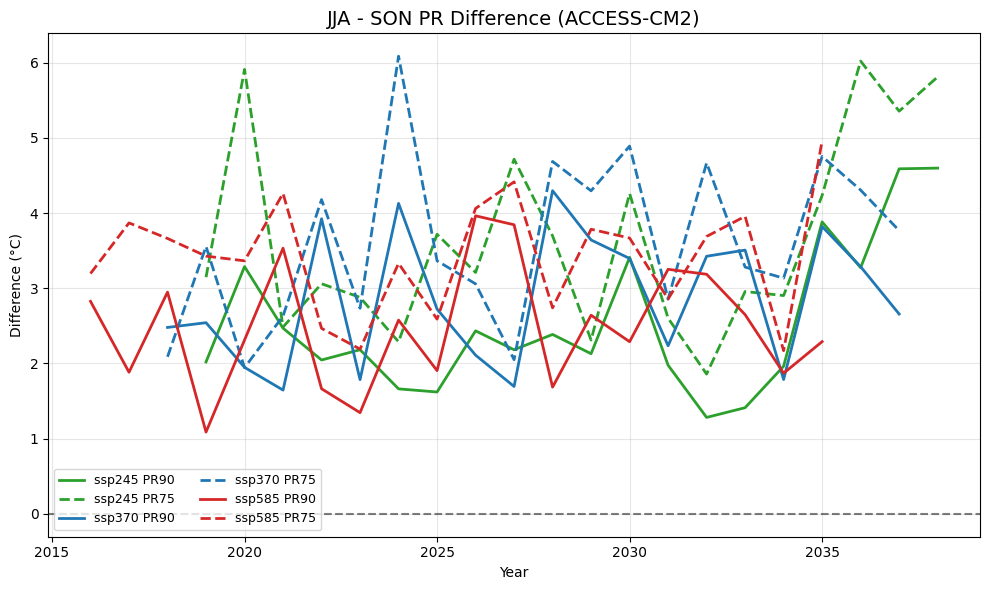

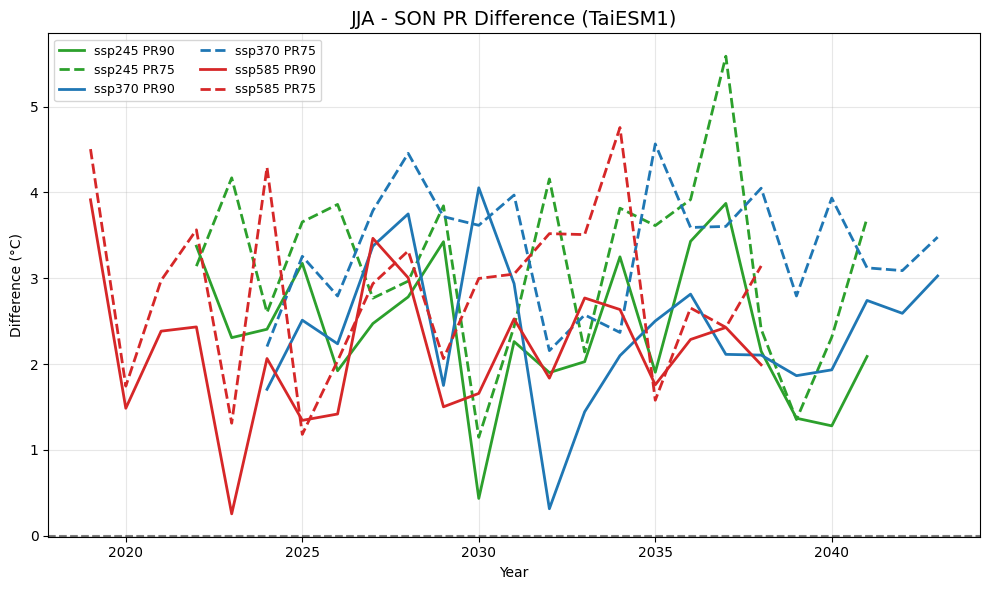

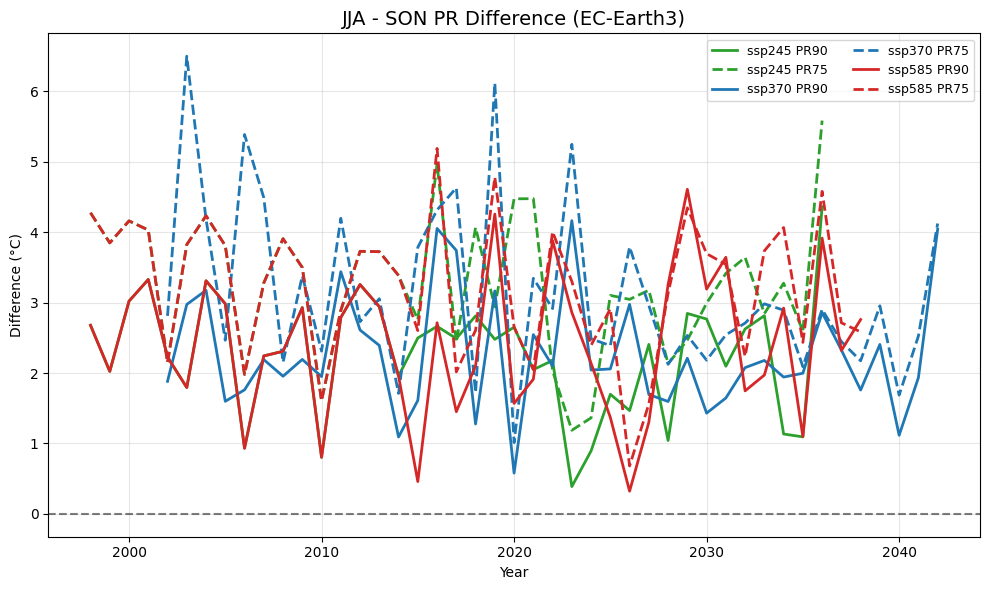

In [40]:
import matplotlib.pyplot as plt
import numpy as np

season_pair = ["JJA", "SON"]

models = ["ACCESS-CM2", "TaiESM1", "EC-Earth3"]

color_map = {
    "ssp245": "tab:green",
    "ssp370": "tab:blue",
    "ssp585": "tab:red"
}

for model in models:

    plt.figure(figsize=(10,6))

    for ssp in target_ssps:

        sub = daily_result[
            (daily_result["model"] == model) &
            (daily_result["ssp"] == ssp) &
            (daily_result["season"].isin(season_pair))
        ].copy()

        years = sorted(sub["season_year"].dropna().astype(int).unique())

        pr90_diff = []
        pr75_diff = []
        valid_years = []

        for y in years:

            pr90_dict = {}
            pr75_dict = {}

            for season in season_pair:
                vals = sub.loc[
                    (sub["season_year"] == y) &
                    (sub["season"] == season),
                    "tmax"
                ].dropna().values

                if len(vals) > 0:
                    pr90_dict[season] = np.percentile(vals, 90)
                    pr75_dict[season] = np.percentile(vals, 75)

            if len(pr90_dict) == 2:
                pr90_diff.append(pr90_dict["JJA"] - pr90_dict["SON"])
                pr75_diff.append(pr75_dict["JJA"] - pr75_dict["SON"])
                valid_years.append(y)

        if len(valid_years) == 0:
            continue

        color = color_map[ssp]

        # PR90 → 實線
        plt.plot(
            valid_years,
            pr90_diff,
            linestyle="-",
            linewidth=2,
            color=color,
            label=f"{ssp} PR90"
        )

        # PR75 → 虛線
        plt.plot(
            valid_years,
            pr75_diff,
            linestyle="--",
            linewidth=2,
            color=color,
            label=f"{ssp} PR75"
        )

    # 0 baseline（超關鍵）
    plt.axhline(0, linestyle="--", color="black", alpha=0.5)

    plt.title(f"JJA - SON PR Difference ({model})", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Difference (°C)")
    plt.grid(True, alpha=0.3)

    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    plt.show()